# Netflix Content Intelligence & Predictive Analytics System
## End-to-End Data Science Project

**Author:** Akash More  
**Date:** March 2026  
**Objective:** Build comprehensive analytics system for Netflix content strategy optimization

---

## Table of Contents
1. [Business Problem Definition](#phase1)
2. [Data Loading & Initial Exploration](#phase2)
3. [Data Cleaning & Preparation](#phase3)
4. [Feature Engineering](#phase4)
5. [Exploratory Data Analysis (EDA)](#phase5)
6. [Regional & Market Analysis](#phase6)
7. [Time-Series & Trend Analysis](#phase7)
8. [Machine Learning Models](#phase8)
9. [Business KPIs & Metrics](#phase9)
10. [Business Recommendations](#phase10)

## PHASE 1: Business Problem Definition <a name="phase1"></a>

### Core Business Questions:
1. What type of content (Movies vs TV Shows) performs better across regions? 
2. How has Netflix’s content strategy changed over time? 
3. Which countries contribute the most content, and where is growth slowing? 
4. What duration patterns maximize viewer engagement? 
5. Which genres are over-saturated or under-served? 
6. How can Netflix optimize future content investment?

In [1]:
#import Necessary Libraries 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from datetime import datetime
import re

#ML Librarires
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import xgboost as xgb

# Configuration
warnings.filterwarnings('ignore') # Avoid Warnings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

## PHASE 2: Data Loading & Initial Exploration <a name="phase2"></a>

In [2]:
# Load the dataset
df = pd.read_csv('netflix_titles.csv')

print(f'Dataset Shape: {df.shape}')
print('\n' + '='*150)
print("INITIAL DATA OVERVIEW")
print("="*150)
df.head(10)

Dataset Shape: (8807, 12)

INITIAL DATA OVERVIEW


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [3]:
print("\n" + "="*40)
print("DATA TYPES & MEMORY USAGE")
print("="*40)
df.info()


DATA TYPES & MEMORY USAGE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
#Statistical summary
print("\n" + "="*130)
print("STATISTICAL SUMMARY")
print("="*130)
df.describe(include='all').T


STATISTICAL SUMMARY


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s8807,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Zubaan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Missing values analysis
print("\n" + "="*47)
print("MISSING VALUES ANALYSIS")
print("="*47)

missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': (df.isnull().sum().values / len(df) * 100).round(2)
}).sort_values('Missing_Percentage', ascending=False)
missing_data


MISSING VALUES ANALYSIS


,Column,Missing_Count,Missing_Percentage
3,director,2634,29.91
5,country,831,9.44
4,cast,825,9.37
6,date_added,10,0.11
8,rating,4,0.05
9,duration,3,0.03
0,show_id,0,0.00
1,type,0,0.00
2,title,0,0.00
7,release_year,0,0.00


---
## PHASE 3: Data Cleaning & Preparation <a name="phase3"></a>

### Critical Questions Addressed:
1. How to handle missing values in director, cast, country, rating, date_added, duration?
2. How to standardize inconsistent values?
3. How to handle mixed formats in duration column?
4. How to validate release_year against date_added?
5. How to ensure data integrity?

In [6]:
# Create a copy for cleaning
df_clean = df.copy()

print("STEP 1: Handling Missing Values")
print("="*55)

# 1. Fill missing director with 'Unknown'
df_clean['director'] = df_clean['director'].fillna('Unknown')
print("Director: Missing values filled with 'Unknown'")

# 2. Fill missing cast with 'Unknown'
df_clean['cast'] = df_clean['cast'].fillna('Unknown')
print("Cast: Missing values filled with 'Unknown'")

# 3. Fill missing country with 'Unknown'
df_clean['country'] = df_clean['country'].fillna('Unknown')
print("Country: Missing values filled with 'Unknown'")

# 4. Fill missing rating with mode (most common rating)
mode_rating = df_clean['rating'].mode()[0]
df_clean['rating'] = df_clean['rating'].fillna(mode_rating)
print(f"Rating: Missing values filled with mode '{mode_rating}'")

# 5. Handle date_added
# Drop rows where date_added is missing (critical for time series analysis)
rows_before = len(df_clean)
df_clean = df_clean.dropna(subset=['date_added'])
rows_after = len(df_clean)
print(f"Date_added: Dropped {rows_before - rows_after} rows with missing dates")

# 6. Duration should not have missing values - drop if any
df_clean = df_clean.dropna(subset=['duration'])
print(f"Duration: Ensured no missing values (current count: {df_clean['duration'].isnull().sum()})")

print(f"\nDataset shape after cleaning: {df_clean.shape}")

STEP 1: Handling Missing Values
Director: Missing values filled with 'Unknown'
Cast: Missing values filled with 'Unknown'
Country: Missing values filled with 'Unknown'
Rating: Missing values filled with mode 'TV-MA'
Date_added: Dropped 10 rows with missing dates
Duration: Ensured no missing values (current count: 0)

Dataset shape after cleaning: (8794, 12)


In [7]:
print("\n" + "="*90)
print("STEP 2: Standardizing Values")
print("="*90)

# Standardize type column
df_clean['type'] = df_clean['type'].str.strip().str.title()
print(f'Type values: {df_clean['type'].unique()}')

#Standardize Type column
df_clean['rating'] = df_clean['rating'].str.strip().str.upper()
print(f'Rating Categories: {df_clean['rating'].nunique()} unique ratings')

#Standardize rating column
df_clean['rating'] = df_clean['rating'].str.strip().str.upper()
print(f'Rating categories: {df_clean['rating'].unique()} unique rating')

# Standardize country names (take first country if multiple)
df_clean['primary_country'] = df_clean['country'].apply(lambda x: x.split(',')[0].strip()if pd.notna(x) else 'Unknown')
print(f'Primary country extracted from multi-country entries')

print('\n Standardization complete!')


STEP 2: Standardizing Values
Type values: ['Movie' 'Tv Show']
Rating Categories: 14 unique ratings
Rating categories: ['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G'
 'NC-17' 'NR' 'TV-Y7-FV' 'UR'] unique rating
Primary country extracted from multi-country entries

 Standardization complete!


In [8]:
print("\n" + "="*40)
print("STEP 3: Parsing Duration Column")
print("="*40)

# Extract numeric duration and unit
def parse_duration(duration_str):
    '''Parse duration string into numeric value and unit'''
    if pd.isna(duration_str):
        return np.nan, np.nan

    # Extract number and unit 
    match = re.search(r'(\d+)\s*(\w+)', str(duration_str))
    if match:
        return int(match.group(1)), match.group(2).lower()
    return np.nan, np.nna

df_clean[['duration_value','duration_unit']] = df_clean['duration'].apply(
    lambda x: pd.Series(parse_duration(x))
)

# Create separate columns for movies (minutes) and TV shows (seasons)
df_clean['duration_minutes'] = df_clean.apply(
    lambda row: row['duration_value'] if row['duration_unit'] in ['min', 'minute', 'minutes'] else np.nan, 
    axis=1
)

df_clean['duration_seasons'] = df_clean.apply(
    lambda row: row['duration_value'] if row['duration_unit'] in ['season', 'seasons'] else np.nan, 
    axis=1
)

print(f"Duration parsed into:")
print(f"  - Movies: {df_clean['duration_minutes'].notna().sum()} entries with minutes")
print(f"  - TV Shows: {df_clean['duration_seasons'].notna().sum()} entries with seasons")
print(f"\nDuration statistics:")
print(f"  Movies: {df_clean['duration_minutes'].min():.0f} - {df_clean['duration_minutes'].max():.0f} minutes")
print(f"  TV Shows: {df_clean['duration_seasons'].min():.0f} - {df_clean['duration_seasons'].max():.0f} seasons")


STEP 3: Parsing Duration Column
Duration parsed into:
  - Movies: 6128 entries with minutes
  - TV Shows: 2666 entries with seasons

Duration statistics:
  Movies: 3 - 312 minutes
  TV Shows: 1 - 17 seasons


In [9]:
print("\n" + "="*60)
print("STEP 4: Date Processing & Validation")
print("="*60)

# Convert date_added to datetime
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'], errors='coerce')
df_clean = df_clean.dropna(subset=['date_added'])  # Remove any unparseable dates

# Extract date components
df_clean['year_added'] = df_clean['date_added'].dt.year
df_clean['month_added'] = df_clean['date_added'].dt.month
df_clean['day_added'] = df_clean['date_added'].dt.day
df_clean['quarter_added'] = df_clean['date_added'].dt.quarter

print(f" Date parsing complete")
print(f"  Date range: {df_clean['date_added'].min().date()} to {df_clean['date_added'].max().date()}")
print(f"  Years covered: {df_clean['year_added'].min()} - {df_clean['year_added'].max()}")

# Validate release_year against date_added
df_clean['release_year'] = pd.to_numeric(df_clean['release_year'], errors='coerce')
df_clean['year_gap'] = df_clean['year_added'] - df_clean['release_year']

# Flag suspicious entries (added before release)
suspicious = df_clean[df_clean['year_gap'] < 0]
print(f"\n⚠ Validation: Found {len(suspicious)} entries where date_added < release_year")

if len(suspicious) > 0:
    print("Sample suspicious entries:")
    print(suspicious[['title', 'release_year', 'year_added', 'year_gap']].head())
    # Remove suspicious entries
    df_clean = df_clean[df_clean['year_gap'] >= 0]
    print(f"✓ Removed {len(suspicious)} suspicious entries")


STEP 4: Date Processing & Validation
 Date parsing complete
  Date range: 2008-01-01 to 2021-09-25
  Years covered: 2008 - 2021

⚠ Validation: Found 14 entries where date_added < release_year
Sample suspicious entries:
                   title  release_year  year_added  year_gap
1551               Hilda          2021        2020        -1
1696        Polly Pocket          2021        2020        -1
2920       Love Is Blind          2021        2020        -1
3168        Fuller House          2020        2019        -1
3287  Maradona in Mexico          2020        2019        -1
✓ Removed 14 suspicious entries


In [10]:
print("\n" + "="*50)
print("STEP 5: Data Integrity Check")
print("="*50)

# Final missing values check
critical_columns = ['show_id', 'type', 'title', 'release_year', 'rating', 'duration', 'date_added']
missing_critical = df_clean[critical_columns].isnull().sum()

print("\nCritical Columns Missing Values:")
print(missing_critical)

if missing_critical.sum() == 0:
    print("\n✓ All critical columns have zero missing values!")
else:
    print("\n⚠ Warning: Some critical columns still have missing values")

# Check for duplicates
duplicates = df_clean.duplicated(subset=['show_id']).sum()
print(f"\nDuplicate check: {duplicates} duplicate show_ids found")

if duplicates > 0:
    df_clean = df_clean.drop_duplicates(subset=['show_id'], keep='first')
    print(f"✓ Removed {duplicates} duplicates")

print(f"\n" + "="*80)
print("FINAL CLEANED DATASET")
print("="*80)
print(f"Shape: {df_clean.shape}")
print(f"Columns: {df_clean.shape[1]}")
print(f"Records: {df_clean.shape[0]}")
print(f"\nData Cleaning Complete! ✓")


STEP 5: Data Integrity Check

Critical Columns Missing Values:
show_id         0
type            0
title           0
release_year    0
rating          0
duration        0
date_added      0
dtype: int64

✓ All critical columns have zero missing values!

Duplicate check: 0 duplicate show_ids found

FINAL CLEANED DATASET
Shape: (8692, 22)
Columns: 22
Records: 8692

Data Cleaning Complete! ✓


---
## PHASE 4: Feature Engineering <a name="phase4"></a>

### Features to Create:
1. content_age (years since release)
2. is_recent_content (released in last 5 years)
3. primary_genre (first genre from listed_in)
4. content_length_category (short/medium/long)
5. Additional analytical features

In [11]:
print("="*60)
print("FEATURE ENGINEERING PHASE")
print("="*60)

# 1. Content Age
current_year = 2026
df_clean['content_age'] = current_year - df_clean['release_year']
print(f"✓ Feature 1: content_age created (range: {df_clean['content_age'].min():.0f} - {df_clean['content_age'].max():.0f} years)")

# 2. Is Recent Content (last 5 years)
df_clean['is_recent_content'] = (df_clean['content_age'] <= 5).astype(int)
recent_count = df_clean['is_recent_content'].sum()
recent_pct = (recent_count / len(df_clean) * 100)
print(f"✓ Feature 2: is_recent_content created ({recent_count} entries, {recent_pct:.1f}%)")

# 3. Primary Genre
df_clean['primary_genre'] = df_clean['listed_in'].apply(
    lambda x: x.split(',')[0].strip() if pd.notna(x) else 'Unknown'
)
print(f"✓ Feature 3: primary_genre extracted ({df_clean['primary_genre'].nunique()} unique genres)")

# 4. Content Length Category (for Movies)
def categorize_movie_length(minutes):
    if pd.isna(minutes):
        return 'N/A'
    elif minutes < 60:
        return 'Short (<60 min)'
    elif minutes <= 120:
        return 'Medium (60-120 min)'
    else:
        return 'Long (>120 min)'

df_clean['movie_length_category'] = df_clean['duration_minutes'].apply(categorize_movie_length)
print(f"✓ Feature 4a: movie_length_category created")

# Content Length Category (for TV Shows)
def categorize_tv_length(seasons):
    if pd.isna(seasons):
        return 'N/A'
    elif seasons == 1:
        return 'Limited (1 season)'
    elif seasons <= 3:
        return 'Short (2-3 seasons)'
    else:
        return 'Long (4+ seasons)'

df_clean['tv_length_category'] = df_clean['duration_seasons'].apply(categorize_tv_length)
print(f"✓ Feature 4b: tv_length_category created")

# 5. Time to Netflix (how long after release was it added)
df_clean['time_to_netflix'] = df_clean['year_gap']
print(f"✓ Feature 5: time_to_netflix created (avg: {df_clean['time_to_netflix'].mean():.1f} years)")

FEATURE ENGINEERING PHASE
✓ Feature 1: content_age created (range: 5 - 101 years)
✓ Feature 2: is_recent_content created (589 entries, 6.8%)
✓ Feature 3: primary_genre extracted (36 unique genres)
✓ Feature 4a: movie_length_category created
✓ Feature 4b: tv_length_category created
✓ Feature 5: time_to_netflix created (avg: 4.7 years)


In [12]:
# 6. Has International Cast (check if cast includes non-English names or multiple countries)
df_clean['has_international_cast'] = df_clean['country'].apply(
    lambda x: 1 if ',' in str(x) else 0
)
print(f"✓ Feature 6: has_international_cast created")

# 7. Number of listed genres
df_clean['genre_count'] = df_clean['listed_in'].apply(
    lambda x: len(x.split(',')) if pd.notna(x) else 0
)
print(f"✓ Feature 7: genre_count created (avg: {df_clean['genre_count'].mean():.1f} genres per title)")

# 8. Age Group Target (based on rating)
def categorize_age_target(rating):
    kids_ratings = ['G', 'TV-Y', 'TV-Y7', 'TV-G', 'PG', 'TV-PG']
    teen_ratings = ['PG-13', 'TV-14']
    adult_ratings = ['R', 'TV-MA', 'NC-17']
    
    if rating in kids_ratings:
        return 'Kids/Family'
    elif rating in teen_ratings:
        return 'Teens'
    elif rating in adult_ratings:
        return 'Adults'
    else:
        return 'General'

df_clean['age_target'] = df_clean['rating'].apply(categorize_age_target)
print(f"✓ Feature 8: age_target created")

# 9. Production Era
def categorize_era(year):
    if year < 1970:
        return 'Classic (<1970)'
    elif year < 1990:
        return 'Retro (1970-1989)'
    elif year < 2000:
        return '90s (1990-1999)'
    elif year < 2010:
        return '2000s (2000-2009)'
    elif year < 2020:
        return '2010s (2010-2019)'
    else:
        return '2020s (2020+)'

df_clean['production_era'] = df_clean['release_year'].apply(categorize_era)
print(f"✓ Feature 9: production_era created")

# 10. Is Netflix Original (heuristic: added same year as release)
df_clean['is_netflix_original'] = (df_clean['time_to_netflix'] <= 1).astype(int)
originals = df_clean['is_netflix_original'].sum()
originals_pct = (originals / len(df_clean) * 100)
print(f"✓ Feature 10: is_netflix_original created ({originals} titles, {originals_pct:.1f}%)")

print(f"\n" + "="*60)
print("Feature Engineering Complete!")
print(f"Total Features: {df_clean.shape[1]}")
print("="*60)

✓ Feature 6: has_international_cast created
✓ Feature 7: genre_count created (avg: 2.2 genres per title)
✓ Feature 8: age_target created
✓ Feature 9: production_era created
✓ Feature 10: is_netflix_original created (4779 titles, 55.0%)

Feature Engineering Complete!
Total Features: 33


In [13]:
# Display new features
feature_columns = ['title', 'type', 'content_age', 'is_recent_content', 'primary_genre', 
                   'movie_length_category', 'age_target', 'production_era', 'is_netflix_original']
print("\nSample of Engineered Features:")
df_clean[feature_columns].head(10)


Sample of Engineered Features:


,title,type,content_age,is_recent_content,primary_genre,movie_length_category,age_target,production_era,is_netflix_original
0,Dick Johnson Is Dead,Movie,6,0,Documentaries,Medium (60-120 min),Teens,2020s (2020+),1
1,Blood & Water,Tv Show,5,1,International TV Shows,N/A,Adults,2020s (2020+),1
2,Ganglands,Tv Show,5,1,Crime TV Shows,N/A,Adults,2020s (2020+),1
3,Jailbirds New Orleans,Tv Show,5,1,Docuseries,N/A,Adults,2020s (2020+),1
4,Kota Factory,Tv Show,5,1,International TV Shows,N/A,Adults,2020s (2020+),1
5,Midnight Mass,Tv Show,5,1,TV Dramas,N/A,Adults,2020s (2020+),1
6,My Little Pony: A New Generation,Movie,5,1,Children & Family Movies,Medium (60-120 min),Kids/Family,2020s (2020+),1
7,Sankofa,Movie,33,0,Dramas,Long (>120 min),Adults,90s (1990-1999),0
8,The Great British Baking Show,Tv Show,5,1,British TV Shows,N/A,Teens,2020s (2020+),1
9,The Starling,Movie,5,1,Comedies,Medium (60-120 min),Teens,2020s (2020+),1


---
## PHASE 5: Exploratory Data Analysis (EDA) <a name="phase5"></a>

### Key Questions:
1. How has content volume grown year-over-year?
2. Which genres dominate Netflix's catalog?
3. How does content duration differ by genre, country, and type?
4. What ratings dominate Netflix content globally?

EXPLORATORY DATA ANALYSIS


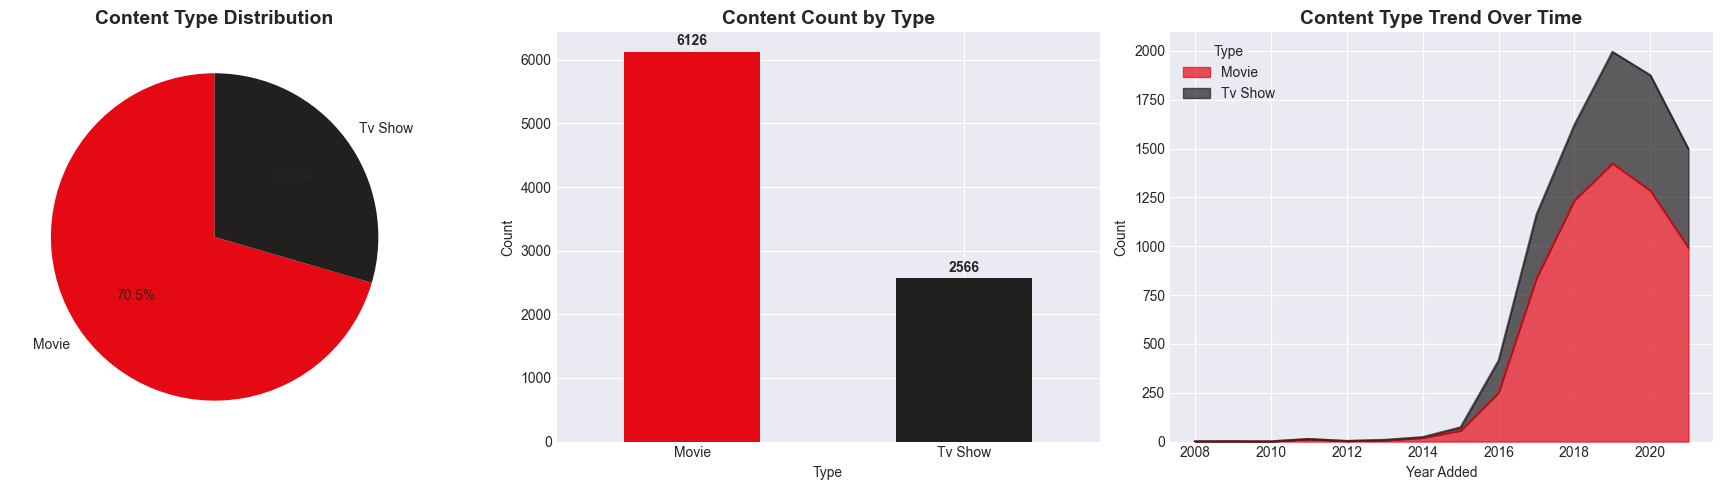

In [14]:
print("="*150)
print("EXPLORATORY DATA ANALYSIS")
print("="*150)

# Create figure and axes (same size, same line)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1 Pie Chart
type_counts = df_clean['type'].value_counts()
colors = ['#E50914', '#221f1f']

axes[0].pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
axes[0].set_title('Content Type Distribution', fontsize=14, fontweight='bold')

# 2 Bar Chart
type_counts.plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title('Content Count by Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

for i, v in enumerate(type_counts):
    axes[1].text(i, v + 100, str(v), ha='center', fontweight='bold')

# 3 Area Chart (FIXED)
type_by_year = df_clean.groupby(['year_added', 'type']).size().unstack(fill_value=0)
type_by_year.plot(
    kind='area',
    stacked=True,
    ax=axes[2],
    color=colors,
    alpha=0.7
)
axes[2].set_title('Content Type Trend Over Time', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Year Added')
axes[2].set_ylabel('Count')
axes[2].legend(title='Type')

plt.tight_layout()
plt.show()

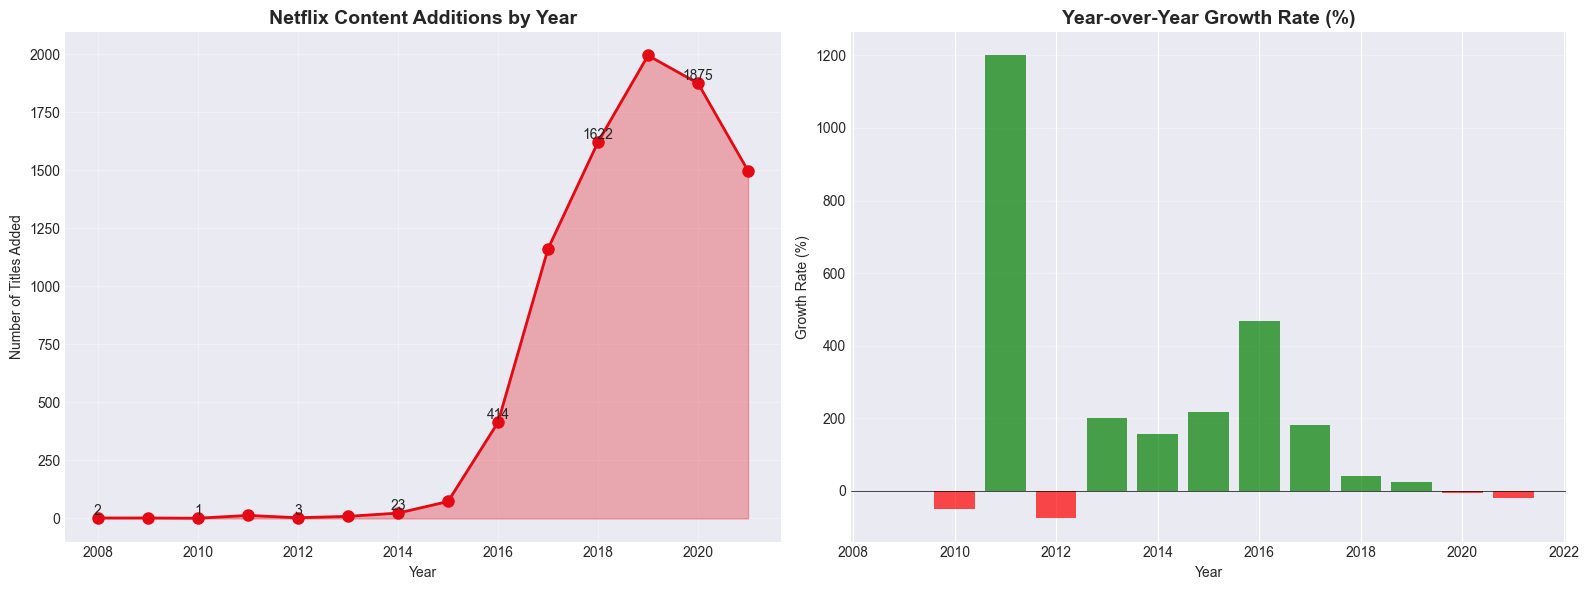


Growth Insights:
  Peak year: 2019 (1995 titles)
  Highest growth: 2011 (1200.0%)
  Recent trend (last 3 years): 1789 titles/year average


In [15]:
# 2. Year-over-Year Content Growth
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
yearly_additions = df_clean.groupby('year_added').size()
plt.plot(yearly_additions.index, yearly_additions.values, marker='o', linewidth=2, markersize=8, color='#E50914')
plt.fill_between(yearly_additions.index, yearly_additions.values, alpha=0.3, color='#E50914')
plt.title('Netflix Content Additions by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.grid(True, alpha=0.3)
for i, v in enumerate(yearly_additions.values):
    if i % 2 == 0:  # Label every other year to avoid clutter
        plt.text(yearly_additions.index[i], v, str(v), ha='center', va='bottom')

plt.subplot(1, 2, 2)
yoy_growth = yearly_additions.pct_change() * 100
colors_growth = ['green' if x > 0 else 'red' for x in yoy_growth]
plt.bar(yoy_growth.index, yoy_growth.values, color=colors_growth, alpha=0.7)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.title('Year-over-Year Growth Rate (%)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nGrowth Insights:")
print(f"  Peak year: {yearly_additions.idxmax()} ({yearly_additions.max()} titles)")
print(f"  Highest growth: {yoy_growth.idxmax()} ({yoy_growth.max():.1f}%)")
print(f"  Recent trend (last 3 years): {yearly_additions.tail(3).mean():.0f} titles/year average")

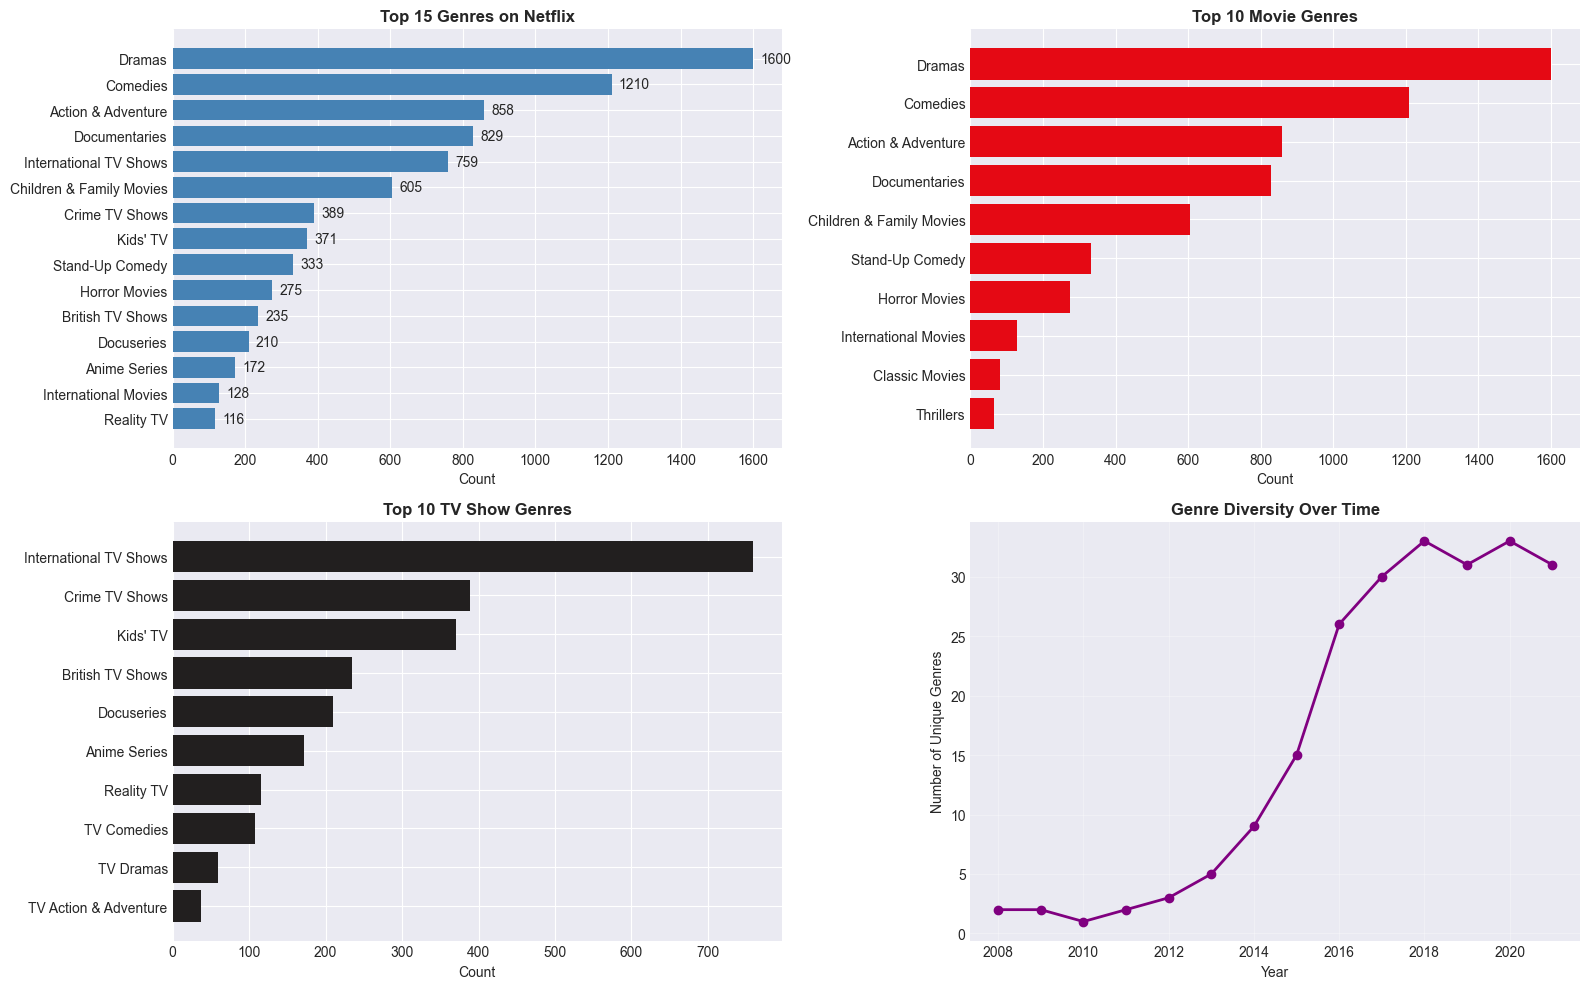


Genre Insights:
  Total unique genres: 36
  Most common genre: Dramas (1600 titles)
  Average genres per title: 2.20


In [16]:
# 3. Top Genres Analysis
plt.figure(figsize=(16, 10))

# Top 15 genres overall
plt.subplot(2, 2, 1)
top_genres = df_clean['primary_genre'].value_counts().head(15)
plt.barh(range(len(top_genres)), top_genres.values, color='steelblue')
plt.yticks(range(len(top_genres)), top_genres.index)
plt.xlabel('Count')
plt.title('Top 15 Genres on Netflix', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
for i, v in enumerate(top_genres.values):
    plt.text(v + 20, i, str(v), va='center')

# Top genres by type
plt.subplot(2, 2, 2)
movie_genres = df_clean[df_clean['type'] == 'Movie']['primary_genre'].value_counts().head(10)
plt.barh(range(len(movie_genres)), movie_genres.values, color='#E50914')
plt.yticks(range(len(movie_genres)), movie_genres.index)
plt.xlabel('Count')
plt.title('Top 10 Movie Genres', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()

plt.subplot(2, 2, 3)
tv_genres = df_clean[df_clean['type'] == 'Tv Show']['primary_genre'].value_counts().head(10)
plt.barh(range(len(tv_genres)), tv_genres.values, color='#221f1f')
plt.yticks(range(len(tv_genres)), tv_genres.index)
plt.xlabel('Count')
plt.title('Top 10 TV Show Genres', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()

# Genre diversity over time
plt.subplot(2, 2, 4)
genre_diversity = df_clean.groupby('year_added')['primary_genre'].nunique()
plt.plot(genre_diversity.index, genre_diversity.values, marker='o', linewidth=2, color='purple')
plt.title('Genre Diversity Over Time', fontsize=12, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Unique Genres')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nGenre Insights:")
print(f"  Total unique genres: {df_clean['primary_genre'].nunique()}")
print(f"  Most common genre: {top_genres.index[0]} ({top_genres.values[0]} titles)")
print(f"  Average genres per title: {df_clean['genre_count'].mean():.2f}")

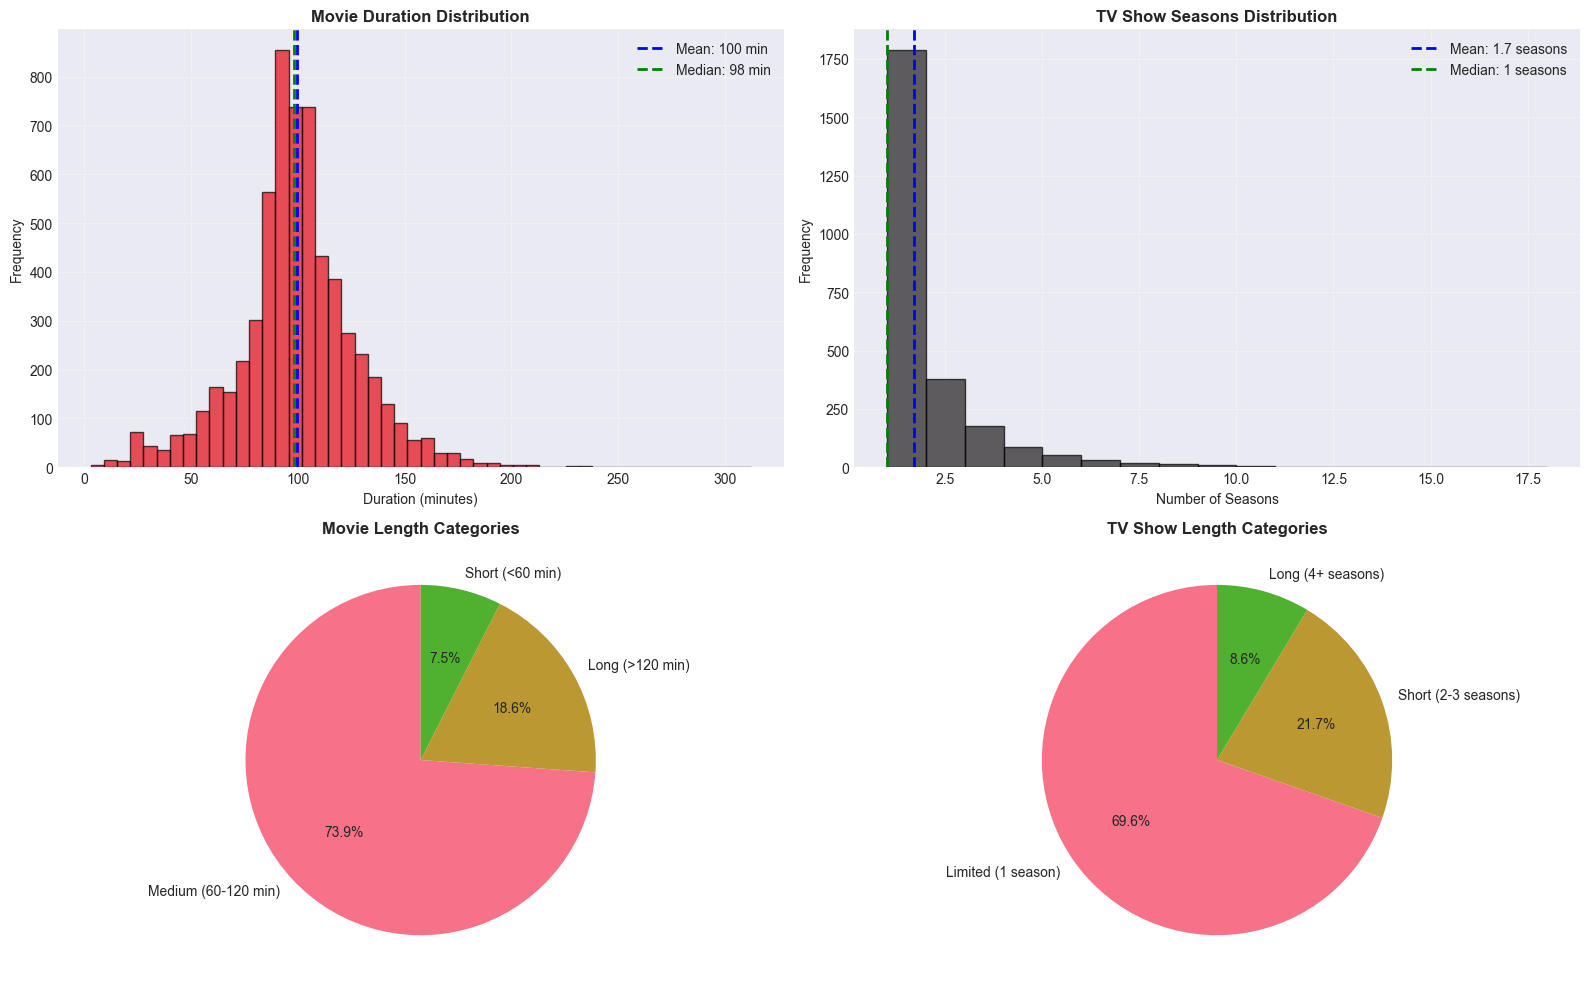


Duration Insights:
  Movies:
    Average: 99.6 minutes
    Median: 98 minutes
    Range: 3 - 312 minutes

  TV Shows:
    Average: 1.68 seasons
    Median: 1 seasons
    Range: 1 - 17 seasons


In [17]:
# 4. Duration Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Movie duration distribution
movie_durations = df_clean[df_clean['type'] == 'Movie']['duration_minutes'].dropna()
axes[0, 0].hist(movie_durations, bins=50, color='#E50914', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(movie_durations.mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean: {movie_durations.mean():.0f} min')
axes[0, 0].axvline(movie_durations.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {movie_durations.median():.0f} min')
axes[0, 0].set_title('Movie Duration Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Duration (minutes)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# TV Show seasons distribution
tv_seasons = df_clean[df_clean['type'] == 'Tv Show']['duration_seasons'].dropna()
axes[0, 1].hist(tv_seasons, bins=range(1, int(tv_seasons.max()) + 2), color='#221f1f', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(tv_seasons.mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean: {tv_seasons.mean():.1f} seasons')
axes[0, 1].axvline(tv_seasons.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {tv_seasons.median():.0f} seasons')
axes[0, 1].set_title('TV Show Seasons Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Number of Seasons')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Movie length categories
movie_length_dist = df_clean[df_clean['type'] == 'Movie']['movie_length_category'].value_counts()
axes[1, 0].pie(movie_length_dist, labels=movie_length_dist.index, autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Movie Length Categories', fontsize=12, fontweight='bold')

# TV show length categories
tv_length_dist = df_clean[df_clean['type'] == 'Tv Show']['tv_length_category'].value_counts()
axes[1, 1].pie(tv_length_dist, labels=tv_length_dist.index, autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('TV Show Length Categories', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nDuration Insights:")
print(f"  Movies:")
print(f"    Average: {movie_durations.mean():.1f} minutes")
print(f"    Median: {movie_durations.median():.0f} minutes")
print(f"    Range: {movie_durations.min():.0f} - {movie_durations.max():.0f} minutes")
print(f"\n  TV Shows:")
print(f"    Average: {tv_seasons.mean():.2f} seasons")
print(f"    Median: {tv_seasons.median():.0f} seasons")
print(f"    Range: {tv_seasons.min():.0f} - {tv_seasons.max():.0f} seasons")

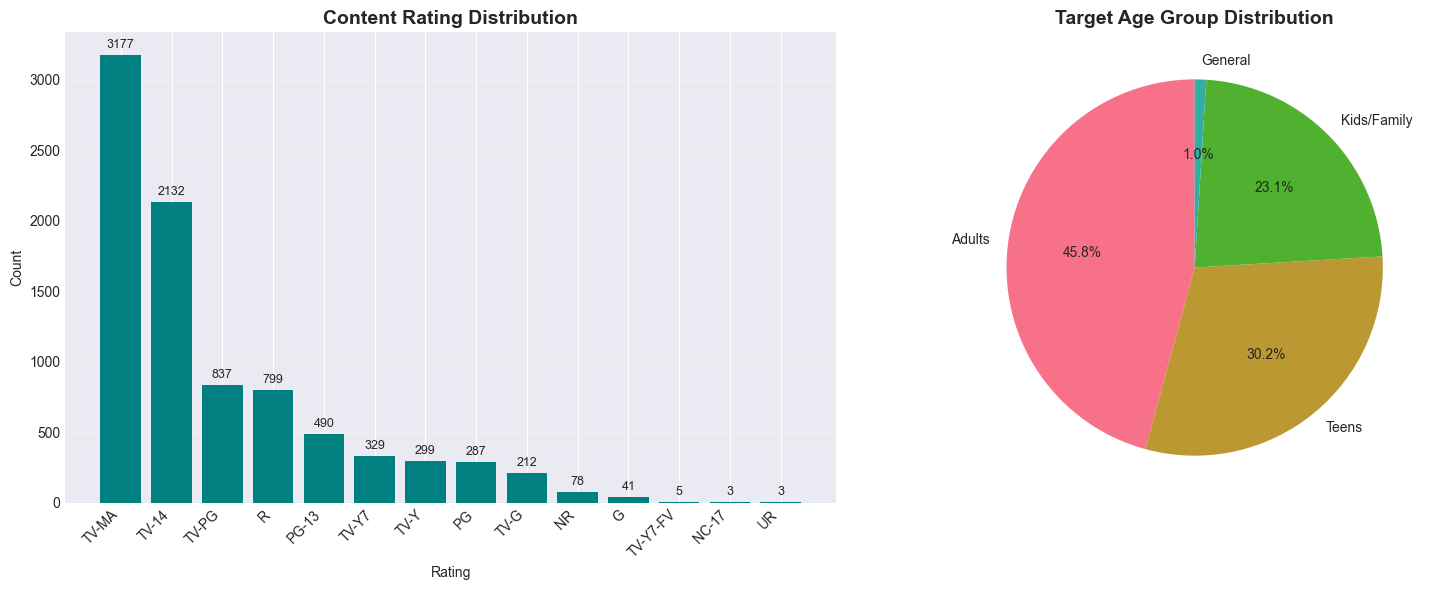


Rating Insights:
  Most common rating: TV-MA (3177 titles)
  Total unique ratings: 14

  Target Audience:
    Adults: 3979 (45.8%)
    Teens: 2622 (30.2%)
    Kids/Family: 2005 (23.1%)
    General: 86 (1.0%)


In [18]:
# 5. Rating Distribution
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
rating_counts = df_clean['rating'].value_counts().head(15)
plt.bar(range(len(rating_counts)), rating_counts.values, color='teal')
plt.xticks(range(len(rating_counts)), rating_counts.index, rotation=45, ha='right')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Content Rating Distribution', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(rating_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontsize=9)

plt.subplot(1, 2, 2)
age_target_counts = df_clean['age_target'].value_counts()
plt.pie(age_target_counts, labels=age_target_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Target Age Group Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nRating Insights:")
print(f"  Most common rating: {rating_counts.index[0]} ({rating_counts.values[0]} titles)")
print(f"  Total unique ratings: {df_clean['rating'].nunique()}")
print(f"\n  Target Audience:")
for age, count in age_target_counts.items():
    print(f"    {age}: {count} ({count/len(df_clean)*100:.1f}%)")

---
## PHASE 6: Regional & Market Analysis <a name="phase6"></a>

### Key Questions:
1. Which countries are over-represented in Netflix content?
2. Which regions show declining content additions?
3. How does genre preference vary by country?
4. Are certain ratings country-specific?

REGIONAL & MARKET ANALYSIS


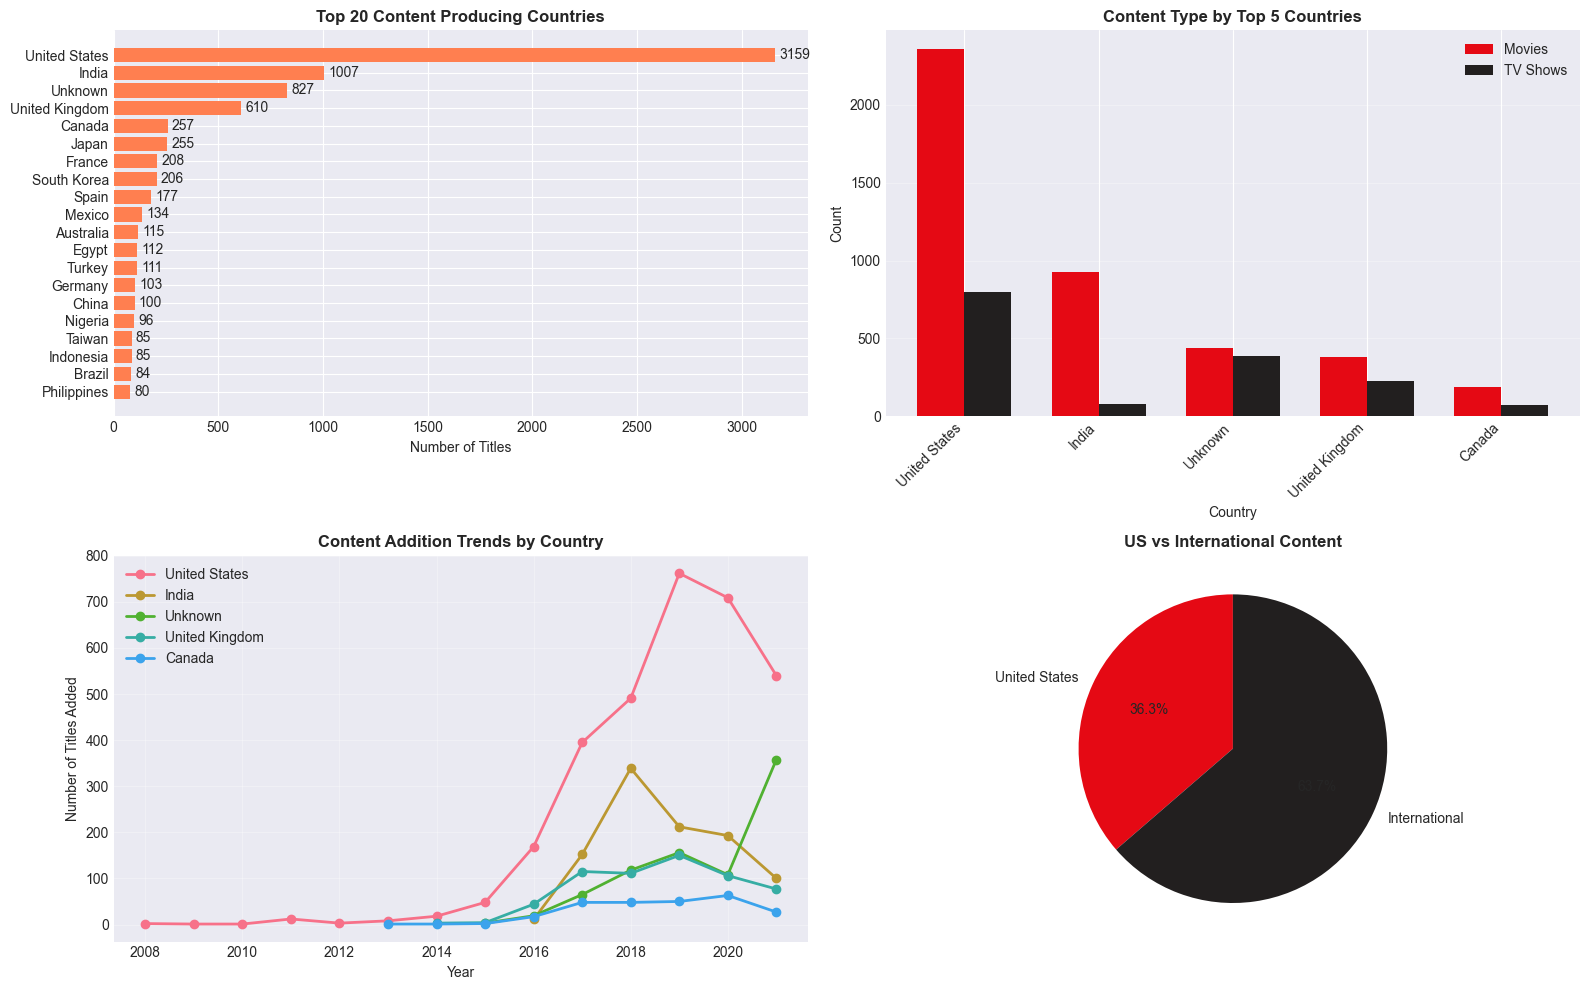


Regional Insights:
  Top producing country: United States (3159 titles)
  Total countries represented: 87
  US content: 3159 (36.3%)
  International content: 5533 (63.7%)


In [19]:
print("="*150)
print("REGIONAL & MARKET ANALYSIS")
print("="*150)

# 1. Top Content Producing Countries
plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
top_countries = df_clean['primary_country'].value_counts().head(20)
plt.barh(range(len(top_countries)), top_countries.values, color='coral')
plt.yticks(range(len(top_countries)), top_countries.index)
plt.xlabel('Number of Titles')
plt.title('Top 20 Content Producing Countries', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
for i, v in enumerate(top_countries.values):
    plt.text(v + 20, i, str(v), va='center')

# 2. Country distribution by content type
plt.subplot(2, 2, 2)
top_5_countries = top_countries.head(5).index
country_type_data = []
for country in top_5_countries:
    movies = len(df_clean[(df_clean['primary_country'] == country) & (df_clean['type'] == 'Movie')])
    tv_shows = len(df_clean[(df_clean['primary_country'] == country) & (df_clean['type'] == 'Tv Show')])
    country_type_data.append([country, movies, tv_shows])

country_type_df = pd.DataFrame(country_type_data, columns=['Country', 'Movies', 'TV Shows'])
x = range(len(country_type_df))
width = 0.35
plt.bar([i - width/2 for i in x], country_type_df['Movies'], width, label='Movies', color='#E50914')
plt.bar([i + width/2 for i in x], country_type_df['TV Shows'], width, label='TV Shows', color='#221f1f')
plt.xlabel('Country')
plt.ylabel('Count')
plt.title('Content Type by Top 5 Countries', fontsize=12, fontweight='bold')
plt.xticks(x, country_type_df['Country'], rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# 3. Content growth by top countries over time
plt.subplot(2, 2, 3)
for country in top_5_countries:
    country_yearly = df_clean[df_clean['primary_country'] == country].groupby('year_added').size()
    plt.plot(country_yearly.index, country_yearly.values, marker='o', label=country, linewidth=2)
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.title('Content Addition Trends by Country', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. International vs Domestic Content
plt.subplot(2, 2, 4)
us_content = len(df_clean[df_clean['primary_country'] == 'United States'])
international_content = len(df_clean[df_clean['primary_country'] != 'United States'])
plt.pie([us_content, international_content], 
        labels=['United States', 'International'],
        autopct='%1.1f%%',
        colors=['#E50914', '#221f1f'],
        startangle=90)
plt.title('US vs International Content', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nRegional Insights:")
print(f"  Top producing country: {top_countries.index[0]} ({top_countries.values[0]} titles)")
print(f"  Total countries represented: {df_clean['primary_country'].nunique()}")
print(f"  US content: {us_content} ({us_content/len(df_clean)*100:.1f}%)")
print(f"  International content: {international_content} ({international_content/len(df_clean)*100:.1f}%)")


Genre Preferences by Top 5 Countries:
  United States: Documentaries (429 titles)
  India: Dramas (404 titles)
  Unknown: International TV Shows (158 titles)
  United Kingdom: British TV Shows (199 titles)
  Canada: Children & Family Movies (39 titles)


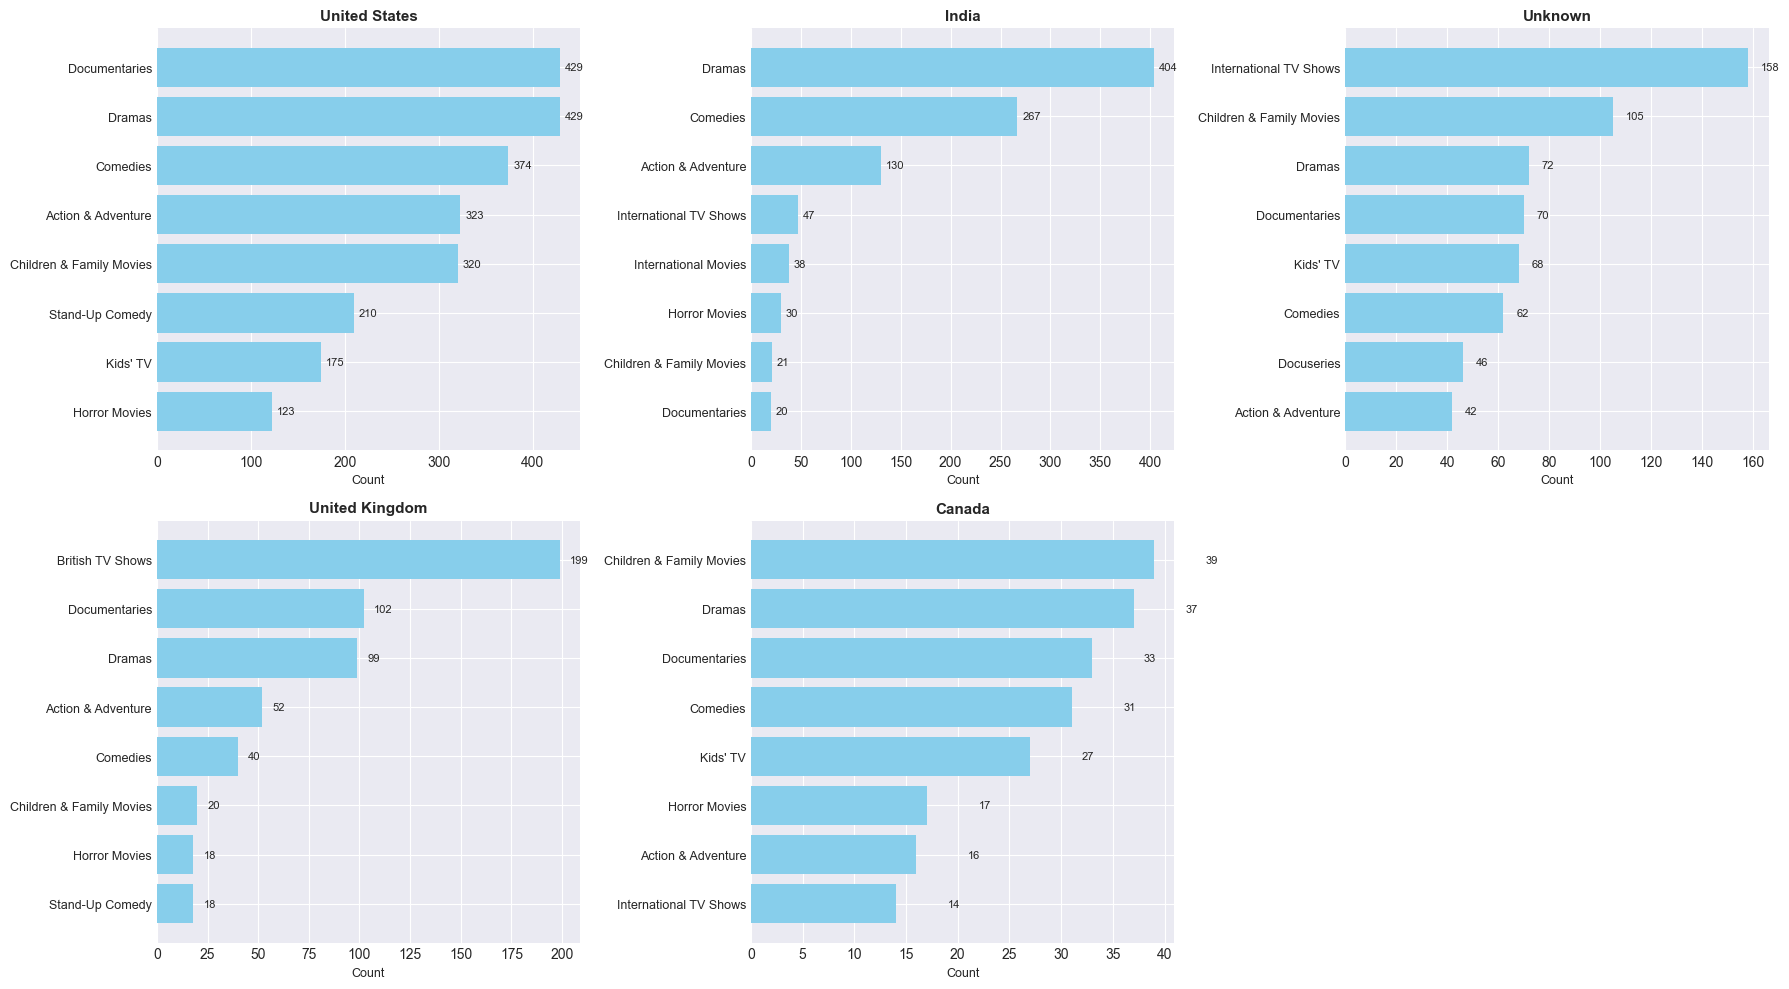

In [20]:
# 5. Genre preferences by country (Top 5 countries)
print("\nGenre Preferences by Top 5 Countries:")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, country in enumerate(top_5_countries):
    country_genres = df_clean[df_clean['primary_country'] == country]['primary_genre'].value_counts().head(8)
    axes[idx].barh(range(len(country_genres)), country_genres.values, color='skyblue')
    axes[idx].set_yticks(range(len(country_genres)))
    axes[idx].set_yticklabels(country_genres.index, fontsize=9)
    axes[idx].set_xlabel('Count', fontsize=9)
    axes[idx].set_title(f'{country}', fontsize=11, fontweight='bold')
    axes[idx].invert_yaxis()
    for i, v in enumerate(country_genres.values):
        axes[idx].text(v + 5, i, str(v), va='center', fontsize=8)
    
    # Print top genre for each country
    print(f"  {country}: {country_genres.index[0]} ({country_genres.values[0]} titles)")

# Remove the 6th subplot if not needed
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()


EMERGING MARKETS ANALYSIS

Top 10 Fastest Growing Markets:
      Country  Recent (3yr)  Older (3yr)    Growth %
        Egypt           110            2 5400.000000
      Nigeria            92            3 2966.666667
  Philippines            75            5 1400.000000
      Unknown           622          202  207.920792
    Indonesia            58           27  114.814815
        Japan           169           85   98.823529
        Italy            43           22   95.454545
United States          2011         1055   90.616114
       Turkey            71           40   77.500000
  South Korea           131           75   74.666667

Top 10 Declining Markets:
       Country  Recent (3yr)  Older (3yr)  Growth %
        Brazil            52           32 62.500000
        France           126           78 61.538462
       Germany            62           39 58.974359
         Spain           102           74 37.837838
        Canada           140          113 23.893805
United Kingdom    

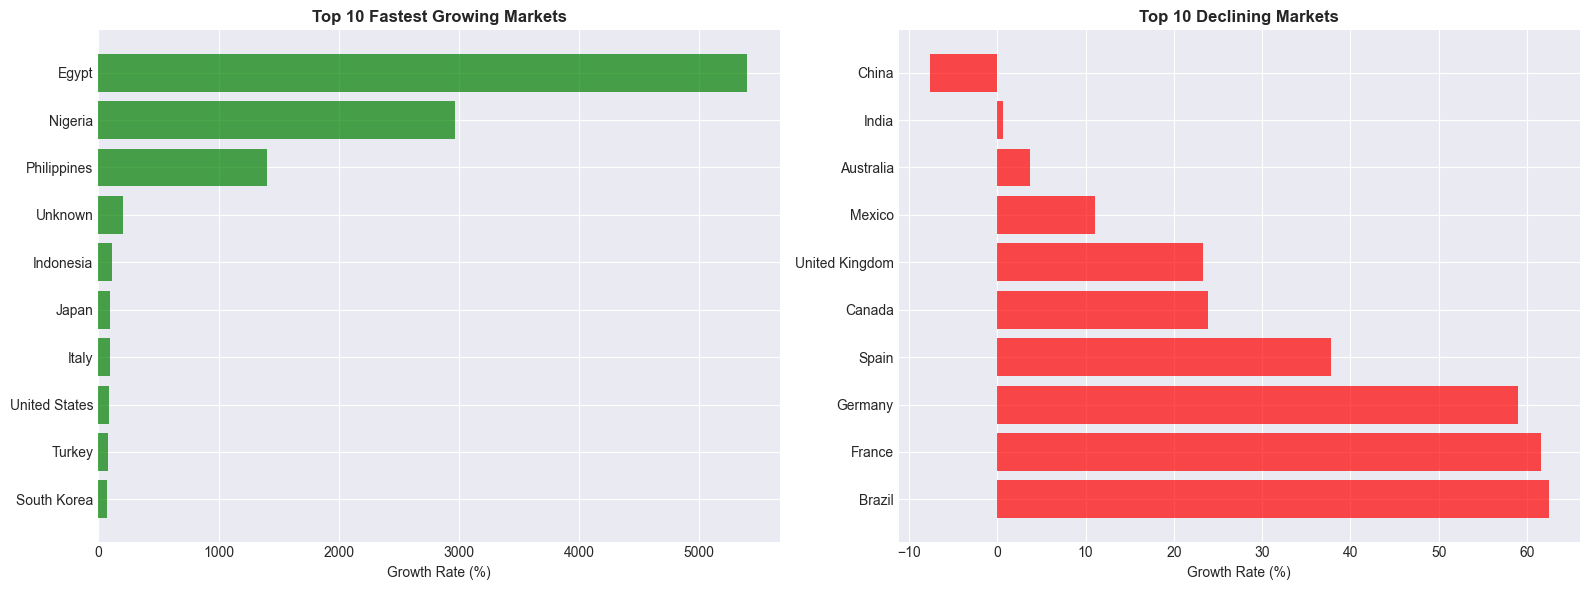

In [21]:
# 6. Emerging markets analysis
print("\n" + "="*80)
print("EMERGING MARKETS ANALYSIS")
print("="*80)

# Countries with fastest growth in last 3 years
recent_years = df_clean['year_added'].max()
recent_data = df_clean[df_clean['year_added'] >= recent_years - 2]
older_data = df_clean[(df_clean['year_added'] < recent_years - 2) & (df_clean['year_added'] >= recent_years - 5)]

recent_countries = recent_data['primary_country'].value_counts()
older_countries = older_data['primary_country'].value_counts()

# Calculate growth
growth_data = []
for country in recent_countries.index[:20]:  # Top 20 countries in recent years
    recent_count = recent_countries.get(country, 0)
    older_count = older_countries.get(country, 1)  # Avoid division by zero
    growth_rate = ((recent_count - older_count) / older_count * 100)
    growth_data.append([country, recent_count, older_count, growth_rate])

growth_df = pd.DataFrame(growth_data, columns=['Country', 'Recent (3yr)', 'Older (3yr)', 'Growth %'])
growth_df = growth_df.sort_values('Growth %', ascending=False)

print("\nTop 10 Fastest Growing Markets:")
print(growth_df.head(10).to_string(index=False))

print("\nTop 10 Declining Markets:")
print(growth_df.tail(10).to_string(index=False))

# Visualize
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
top_growth = growth_df.head(10)
plt.barh(range(len(top_growth)), top_growth['Growth %'], color='green', alpha=0.7)
plt.yticks(range(len(top_growth)), top_growth['Country'])
plt.xlabel('Growth Rate (%)')
plt.title('Top 10 Fastest Growing Markets', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()

plt.subplot(1, 2, 2)
bottom_growth = growth_df.tail(10).sort_values('Growth %')
plt.barh(range(len(bottom_growth)), bottom_growth['Growth %'], color='red', alpha=0.7)
plt.yticks(range(len(bottom_growth)), bottom_growth['Country'])
plt.xlabel('Growth Rate (%)')
plt.title('Top 10 Declining Markets', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

---
## PHASE 7: Time-Series & Trend Analysis <a name="phase7"></a>

### Key Questions:
1. How has Netflix's focus shifted over time (Movies → TV Shows)?
2. What content types increased after 2015?
3. Is Netflix investing more in shorter or longer content?
4. Are recent releases better diversified by genre?

TIME-SERIES & TREND ANALYSIS


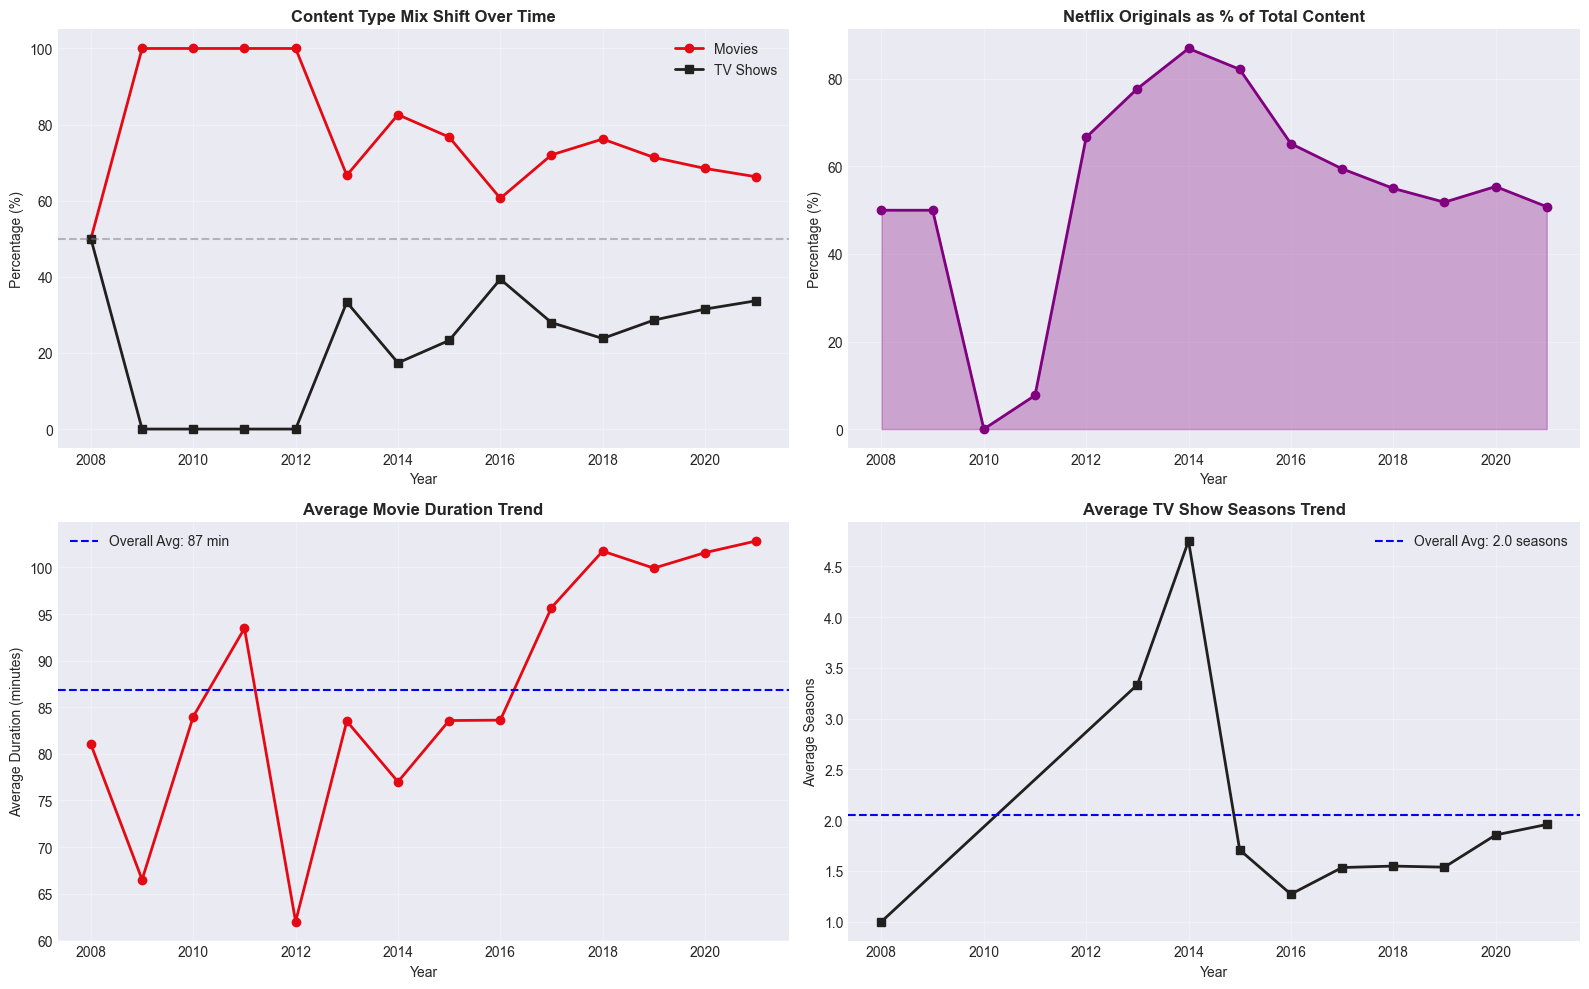


Trend Insights:
  Movie percentage (2015): 76.7%
  Movie percentage (latest): 66.3%
  Average movie duration trend: 101 min (last 3 years)
  Average TV seasons trend: 1.8 (last 3 years)


In [22]:
print("="*150)
print("TIME-SERIES & TREND ANALYSIS")
print("="*150)

# 1. Content Type Shift Over Time
plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
type_by_year = df_clean.groupby(['year_added', 'type']).size().unstack(fill_value=0)
type_pct = type_by_year.div(type_by_year.sum(axis=1), axis=0) * 100
plt.plot(type_pct.index, type_pct['Movie'], marker='o', label='Movies', linewidth=2, color='#E50914')
plt.plot(type_pct.index, type_pct.get('Tv Show', []), marker='s', label='TV Shows', linewidth=2, color='#221f1f')
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.title('Content Type Mix Shift Over Time', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=50, color='gray', linestyle='--', alpha=0.5)

# 2. Netflix Original Content Trend
plt.subplot(2, 2, 2)
original_by_year = df_clean.groupby(['year_added', 'is_netflix_original']).size().unstack(fill_value=0)
if 1 in original_by_year.columns:
    original_pct = (original_by_year[1] / (original_by_year[0] + original_by_year[1]) * 100)
    plt.plot(original_pct.index, original_pct.values, marker='o', linewidth=2, color='purple')
    plt.fill_between(original_pct.index, original_pct.values, alpha=0.3, color='purple')
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.title('Netflix Originals as % of Total Content', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

# 3. Average Movie Duration Over Time
plt.subplot(2, 2, 3)
movie_duration_trend = df_clean[df_clean['type'] == 'Movie'].groupby('year_added')['duration_minutes'].mean()
plt.plot(movie_duration_trend.index, movie_duration_trend.values, marker='o', linewidth=2, color='#E50914')
plt.axhline(y=movie_duration_trend.mean(), color='blue', linestyle='--', 
            label=f'Overall Avg: {movie_duration_trend.mean():.0f} min')
plt.xlabel('Year')
plt.ylabel('Average Duration (minutes)')
plt.title('Average Movie Duration Trend', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Average TV Show Seasons Over Time
plt.subplot(2, 2, 4)
tv_seasons_trend = df_clean[df_clean['type'] == 'Tv Show'].groupby('year_added')['duration_seasons'].mean()
plt.plot(tv_seasons_trend.index, tv_seasons_trend.values, marker='s', linewidth=2, color='#221f1f')
plt.axhline(y=tv_seasons_trend.mean(), color='blue', linestyle='--',
            label=f'Overall Avg: {tv_seasons_trend.mean():.1f} seasons')
plt.xlabel('Year')
plt.ylabel('Average Seasons')
plt.title('Average TV Show Seasons Trend', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTrend Insights:")
print(f"  Movie percentage (2015): {type_pct.loc[2015, 'Movie']:.1f}%" if 2015 in type_pct.index else "  2015 data not available")
print(f"  Movie percentage (latest): {type_pct.iloc[-1]['Movie']:.1f}%")
print(f"  Average movie duration trend: {movie_duration_trend.iloc[-3:].mean():.0f} min (last 3 years)")
print(f"  Average TV seasons trend: {tv_seasons_trend.iloc[-3:].mean():.1f} (last 3 years)")

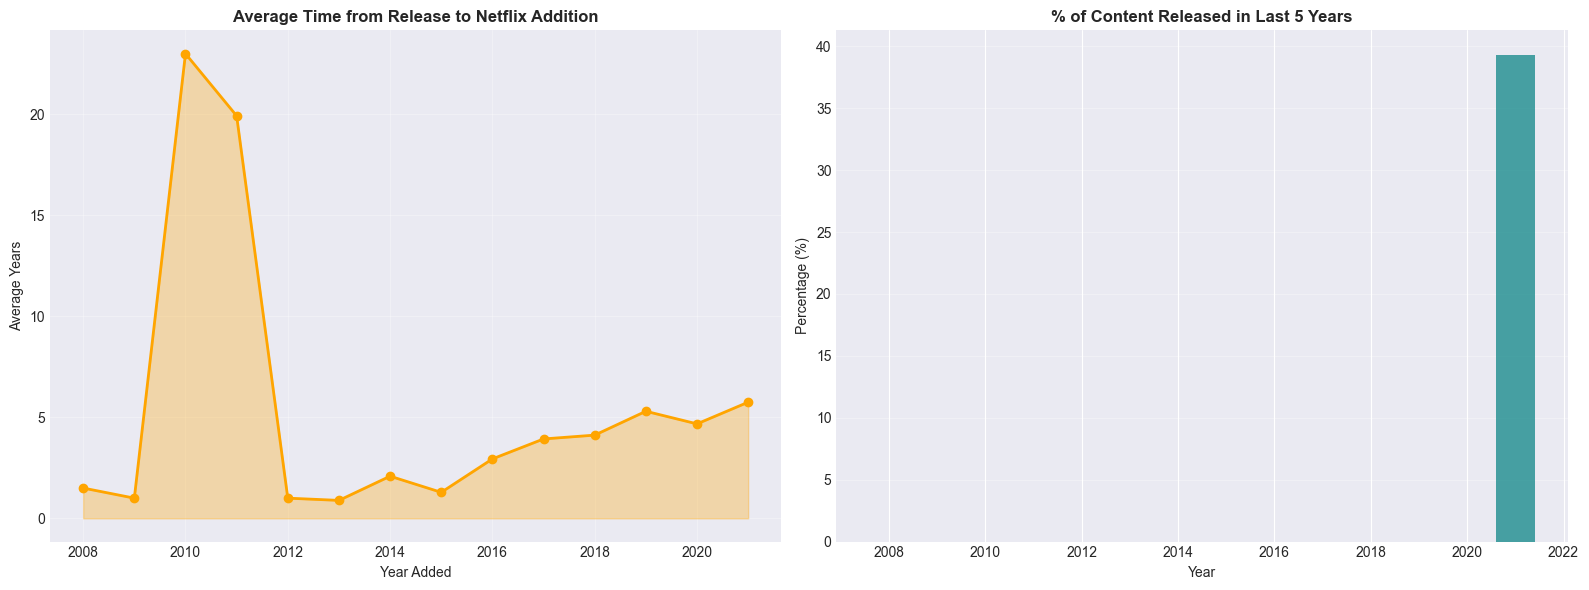


Content Freshness Insights:
  Average time to Netflix (overall): 4.7 years
  Average time to Netflix (last 3 years): 5.2 years
  Recent content % (latest year): 39.3%


In [23]:
# 5. Content Release to Addition Time Lag
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
time_lag_trend = df_clean.groupby('year_added')['time_to_netflix'].mean()
plt.plot(time_lag_trend.index, time_lag_trend.values, marker='o', linewidth=2, color='orange')
plt.fill_between(time_lag_trend.index, time_lag_trend.values, alpha=0.3, color='orange')
plt.xlabel('Year Added')
plt.ylabel('Average Years')
plt.title('Average Time from Release to Netflix Addition', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
recent_content_trend = df_clean.groupby('year_added')['is_recent_content'].mean() * 100
plt.bar(recent_content_trend.index, recent_content_trend.values, color='teal', alpha=0.7)
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.title('% of Content Released in Last 5 Years', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nContent Freshness Insights:")
print(f"  Average time to Netflix (overall): {df_clean['time_to_netflix'].mean():.1f} years")
print(f"  Average time to Netflix (last 3 years): {df_clean[df_clean['year_added'] >= df_clean['year_added'].max() - 2]['time_to_netflix'].mean():.1f} years")
print(f"  Recent content % (latest year): {recent_content_trend.iloc[-1]:.1f}%")

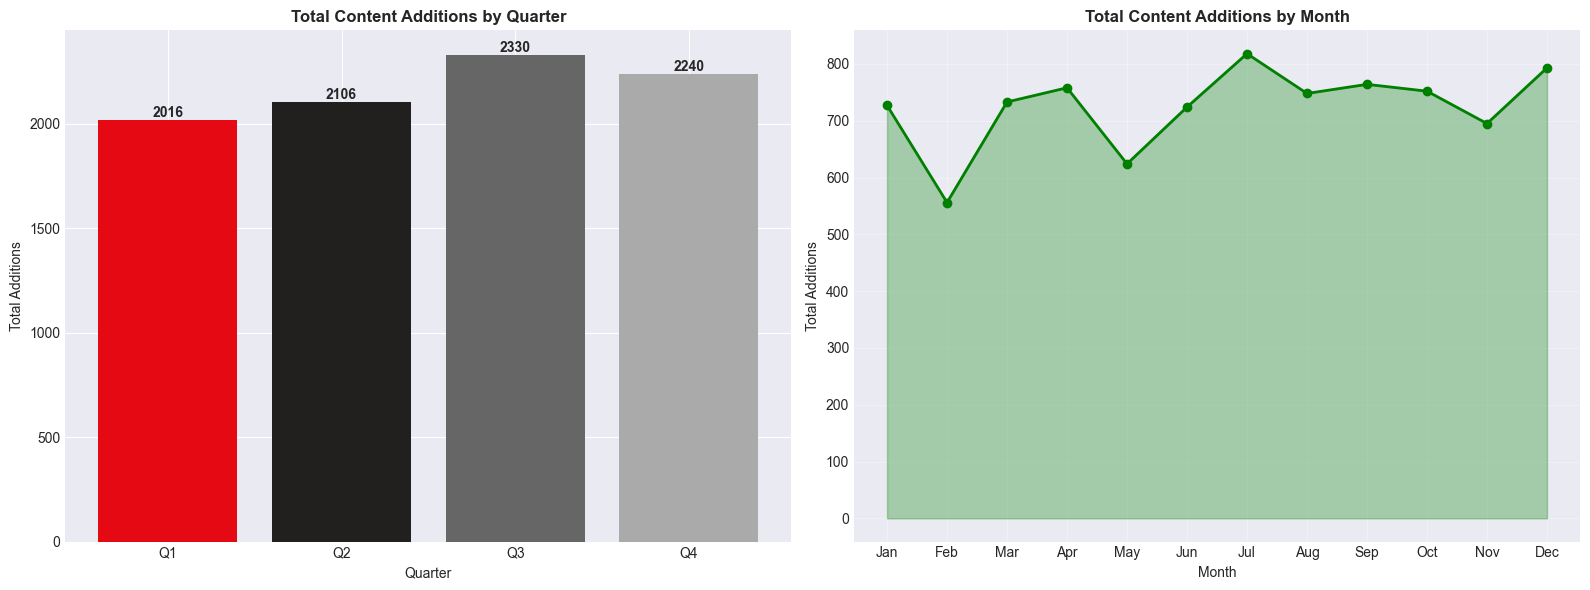


Seasonal Insights:
  Highest addition quarter: Q3 (2330 titles)
  Highest addition month: 7 (818 titles)
  Lowest addition month: 2 (556 titles)


In [24]:
# 6. Quarterly addition patterns
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
quarterly_additions = df_clean.groupby('quarter_added').size()
plt.bar(quarterly_additions.index, quarterly_additions.values, color=['#E50914', '#221f1f', '#666666', '#AAAAAA'])
plt.xlabel('Quarter')
plt.ylabel('Total Additions')
plt.title('Total Content Additions by Quarter', fontsize=12, fontweight='bold')
plt.xticks([1, 2, 3, 4], ['Q1', 'Q2', 'Q3', 'Q4'])
for i, v in enumerate(quarterly_additions.values):
    plt.text(i+1, v, str(v), ha='center', va='bottom', fontweight='bold')

plt.subplot(1, 2, 2)
monthly_additions = df_clean.groupby('month_added').size()
plt.plot(monthly_additions.index, monthly_additions.values, marker='o', linewidth=2, color='green')
plt.fill_between(monthly_additions.index, monthly_additions.values, alpha=0.3, color='green')
plt.xlabel('Month')
plt.ylabel('Total Additions')
plt.title('Total Content Additions by Month', fontsize=12, fontweight='bold')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSeasonal Insights:")
print(f"  Highest addition quarter: Q{quarterly_additions.idxmax()} ({quarterly_additions.max()} titles)")
print(f"  Highest addition month: {monthly_additions.idxmax()} ({monthly_additions.max()} titles)")
print(f"  Lowest addition month: {monthly_additions.idxmin()} ({monthly_additions.min()} titles)")

---
## PHASE 8: Machine Learning Models <a name="phase8"></a>

### Objectives:
1. Predict content type (Movie vs TV Show)
2. Predict duration category
3. Compare model performances

### Models:
- Logistic Regression
- Random Forest
- XGBoost

In [25]:
print("="*150)
print("MACHINE LEARNING - MODEL PREPARATION")
print("="*150)

# Prepare data for ML
ml_df = df_clean.copy()

# Select features for modeling
print("\nFeature Selection:")

# Encode categorical variables
le_rating = LabelEncoder()
le_genre = LabelEncoder()
le_country = LabelEncoder()
le_age_target = LabelEncoder()

ml_df['rating_encoded'] = le_rating.fit_transform(ml_df['rating'])
ml_df['genre_encoded'] = le_genre.fit_transform(ml_df['primary_genre'])
ml_df['country_encoded'] = le_country.fit_transform(ml_df['primary_country'])
ml_df['age_target_encoded'] = le_age_target.fit_transform(ml_df['age_target'])

print("✓ Categorical variables encoded")

# Create target variable for classification
ml_df['type_encoded'] = (ml_df['type'] == 'Movie').astype(int)  # 1 for Movie, 0 for TV Show
print("✓ Target variable created")

# Feature set
feature_columns = [
    'release_year',
    'rating_encoded',
    'genre_encoded',
    'country_encoded',
    'content_age',
    'is_recent_content',
    'genre_count',
    'age_target_encoded',
    'time_to_netflix',
    'has_international_cast',
    'is_netflix_original'
]

print(f"\nFeatures selected: {len(feature_columns)}")
print("Features:", feature_columns)

# Prepare X and y
X = ml_df[feature_columns]
y = ml_df['type_encoded']

print(f"\nDataset shape: {X.shape}")
print(f"Class distribution:")
print(f"  Movies (1): {y.sum()} ({y.sum()/len(y)*100:.1f}%)")
print(f"  TV Shows (0): {(y==0).sum()} ({(y==0).sum()/len(y)*100:.1f}%)")

MACHINE LEARNING - MODEL PREPARATION

Feature Selection:
✓ Categorical variables encoded
✓ Target variable created

Features selected: 11
Features: ['release_year', 'rating_encoded', 'genre_encoded', 'country_encoded', 'content_age', 'is_recent_content', 'genre_count', 'age_target_encoded', 'time_to_netflix', 'has_international_cast', 'is_netflix_original']

Dataset shape: (8692, 11)
Class distribution:
  Movies (1): 6126 (70.5%)
  TV Shows (0): 2566 (29.5%)


In [26]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n" + "="*50)
print("DATA SPLIT")
print("="*50)
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Features scaled using StandardScaler")


DATA SPLIT
Training set: 6953 samples (80.0%)
Test set: 1739 samples (20.0%)

✓ Features scaled using StandardScaler



MODEL 1: LOGISTIC REGRESSION

Training Accuracy: 0.7851
Test Accuracy: 0.7809
Training F1-Score: 0.8568
Test F1-Score: 0.8549

Classification Report:
              precision    recall  f1-score   support

     TV Show       0.69      0.46      0.55       513
       Movie       0.80      0.92      0.85      1226

    accuracy                           0.78      1739
   macro avg       0.75      0.69      0.70      1739
weighted avg       0.77      0.78      0.77      1739



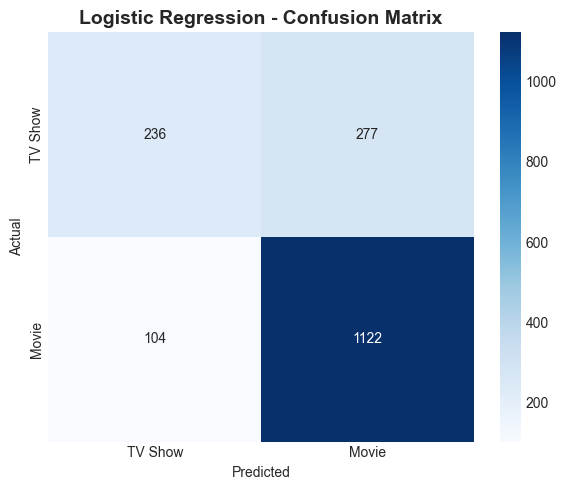

In [27]:
print("\n" + "="*80)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*80)

# Train Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_train_pred = lr_model.predict(X_train_scaled)
lr_test_pred = lr_model.predict(X_test_scaled)

# Evaluate
lr_train_acc = accuracy_score(y_train, lr_train_pred)
lr_test_acc = accuracy_score(y_test, lr_test_pred)
lr_train_f1 = f1_score(y_train, lr_train_pred)
lr_test_f1 = f1_score(y_test, lr_test_pred)

print(f"\nTraining Accuracy: {lr_train_acc:.4f}")
print(f"Test Accuracy: {lr_test_acc:.4f}")
print(f"Training F1-Score: {lr_train_f1:.4f}")
print(f"Test F1-Score: {lr_test_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, lr_test_pred, target_names=['TV Show', 'Movie']))

# Confusion Matrix
lr_cm = confusion_matrix(y_test, lr_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['TV Show', 'Movie'], 
            yticklabels=['TV Show', 'Movie'])
plt.title('Logistic Regression - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

Training Accuracy: 1.0000
Test Accuracy: 0.9833
Training F1-Score: 1.0000
Test F1-Score: 0.9883


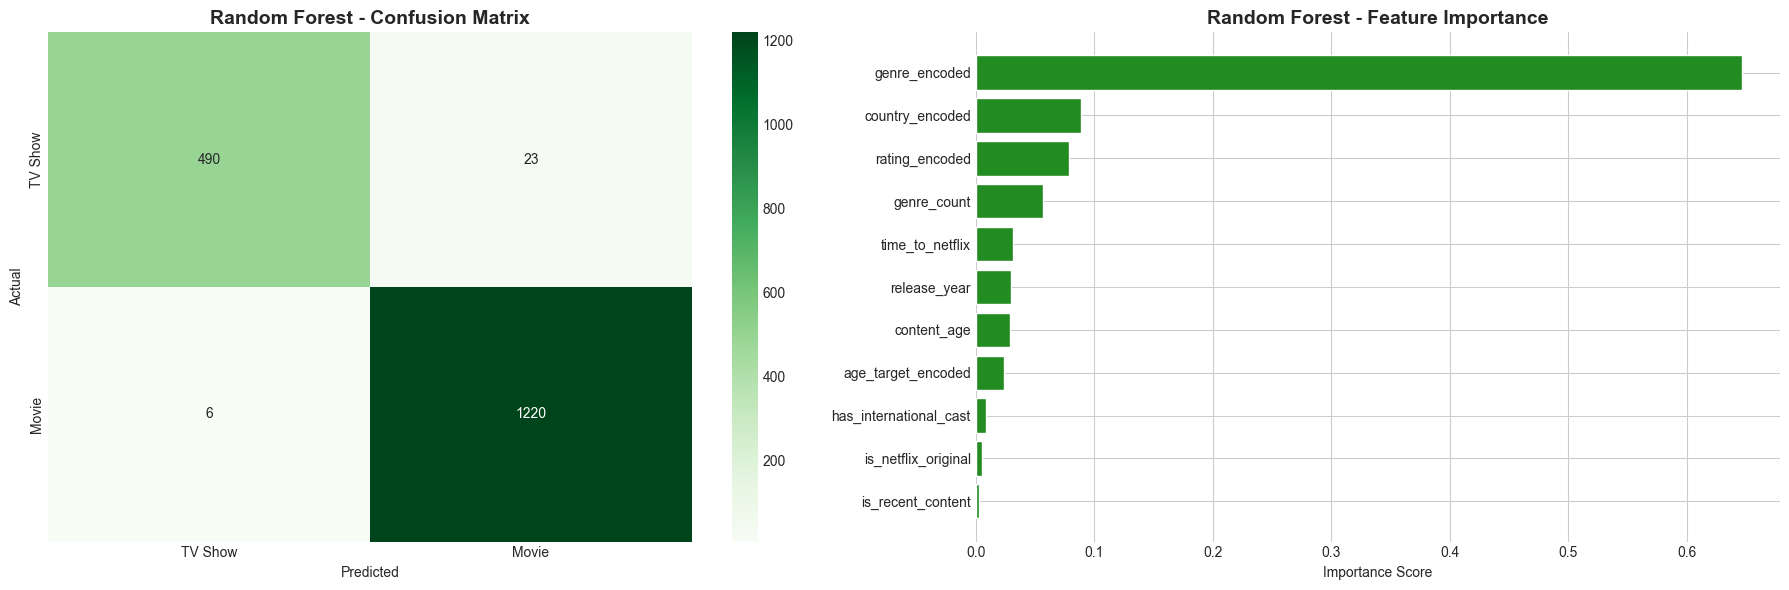

In [28]:
sns.set_style("whitegrid")

# 1️ Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 2️ Make Predictions
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

# 3️ Evaluate
rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc = accuracy_score(y_test, rf_test_pred)
rf_train_f1 = f1_score(y_train, rf_train_pred)
rf_test_f1 = f1_score(y_test, rf_test_pred)

print(f"Training Accuracy: {rf_train_acc:.4f}")
print(f"Test Accuracy: {rf_test_acc:.4f}")
print(f"Training F1-Score: {rf_train_f1:.4f}")
print(f"Test F1-Score: {rf_test_f1:.4f}")

# 4️ Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_test_pred)

# 5️ Feature Importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

# 6️ Plot both in one figure
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Confusion Matrix
sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['TV Show', 'Movie'],
    yticklabels=['TV Show', 'Movie'],
    ax=axes[0]
)
axes[0].set_title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Feature Importance
axes[1].barh(
    feature_importance['feature'],
    feature_importance['importance'],
    color='forestgreen'
)
axes[1].invert_yaxis()
axes[1].set_title('Random Forest - Feature Importance', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()


MODEL 3: XGBOOST

Training Accuracy: 1.0000
Test Accuracy: 0.9994
Training F1-Score: 1.0000
Test F1-Score: 0.9996

Classification Report:
              precision    recall  f1-score   support

     TV Show       1.00      1.00      1.00       513
       Movie       1.00      1.00      1.00      1226

    accuracy                           1.00      1739
   macro avg       1.00      1.00      1.00      1739
weighted avg       1.00      1.00      1.00      1739



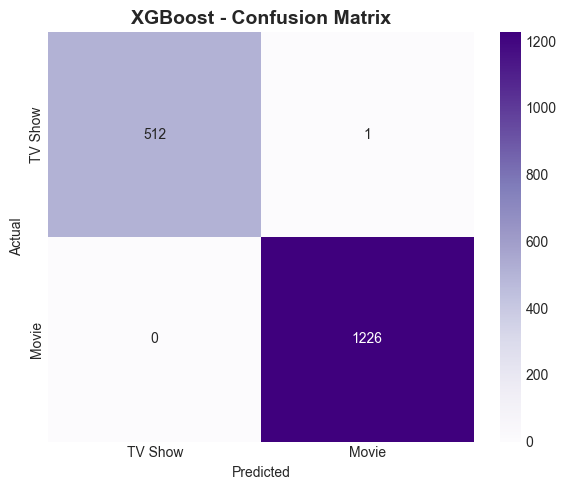

In [29]:
print("\n" + "="*80)
print("MODEL 3: XGBOOST")
print("="*80)

# Train XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', n_jobs=-1)
xgb_model.fit(X_train, y_train)

# Predictions
xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)

# Evaluate
xgb_train_acc = accuracy_score(y_train, xgb_train_pred)
xgb_test_acc = accuracy_score(y_test, xgb_test_pred)
xgb_train_f1 = f1_score(y_train, xgb_train_pred)
xgb_test_f1 = f1_score(y_test, xgb_test_pred)

print(f"\nTraining Accuracy: {xgb_train_acc:.4f}")
print(f"Test Accuracy: {xgb_test_acc:.4f}")
print(f"Training F1-Score: {xgb_train_f1:.4f}")
print(f"Test F1-Score: {xgb_test_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, xgb_test_pred, target_names=['TV Show', 'Movie']))

# Confusion Matrix
xgb_cm = confusion_matrix(y_test, xgb_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Purples', xticklabels=['TV Show', 'Movie'], 
            yticklabels=['TV Show', 'Movie'])
plt.title('XGBoost - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


MODEL COMPARISON

               Model  Train_Accuracy  Test_Accuracy  Train_F1  Test_F1
Logistic Regression        0.785129       0.780909  0.856787 0.854857
      Random Forest        1.000000       0.983324  1.000000 0.988254
            XGBoost        1.000000       0.999425  1.000000 0.999592


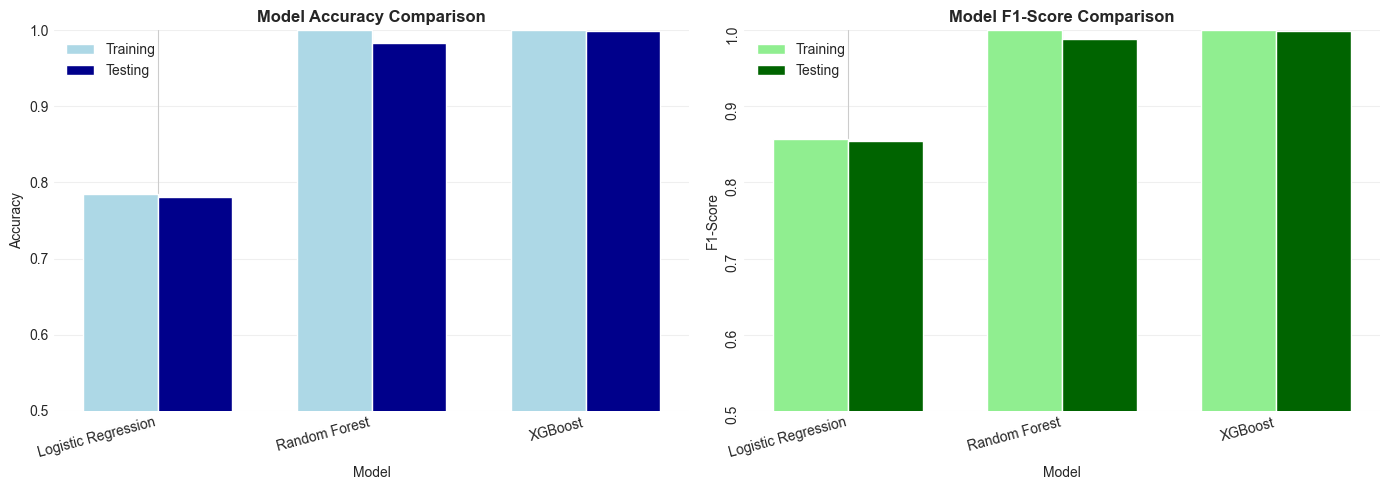


BEST MODEL: XGBoost
   Test Accuracy: 0.9994
   Test F1-Score: 0.9996


In [30]:
print("\n" + "="*150)
print("MODEL COMPARISON")
print("="*150)

# Comparison DataFrame
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Train_Accuracy': [lr_train_acc, rf_train_acc, xgb_train_acc],
    'Test_Accuracy': [lr_test_acc, rf_test_acc, xgb_test_acc],
    'Train_F1': [lr_train_f1, rf_train_f1, xgb_train_f1],
    'Test_F1': [lr_test_f1, rf_test_f1, xgb_test_f1]
})

print("\n", comparison.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
x = range(len(comparison))
width = 0.35
axes[0].bar([i - width/2 for i in x], comparison['Train_Accuracy'], width, label='Training', color='lightblue')
axes[0].bar([i + width/2 for i in x], comparison['Test_Accuracy'], width, label='Testing', color='darkblue')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison['Model'], rotation=15, ha='right')
axes[0].legend()
axes[0].set_ylim([0.5, 1.0])
axes[0].grid(True, alpha=0.3, axis='y')

# F1-Score comparison
axes[1].bar([i - width/2 for i in x], comparison['Train_F1'], width, label='Training', color='lightgreen')
axes[1].bar([i + width/2 for i in x], comparison['Test_F1'], width, label='Testing', color='darkgreen')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('Model F1-Score Comparison', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(comparison['Model'], rotation=15, ha='right')
axes[1].legend()
axes[1].set_ylim([0.5, 1.0])
axes[1].grid(True, alpha=0.3, axis='y')

plt.yticks(rotation=90)
plt.tight_layout()
plt.show()

# Best model
best_model_idx = comparison['Test_Accuracy'].idxmax()
best_model = comparison.loc[best_model_idx, 'Model']
best_accuracy = comparison.loc[best_model_idx, 'Test_Accuracy']
best_f1 = comparison.loc[best_model_idx, 'Test_F1']

print(f"\nBEST MODEL: {best_model}")
print(f"   Test Accuracy: {best_accuracy:.4f}")
print(f"   Test F1-Score: {best_f1:.4f}")

---
## PHASE 9: Business KPIs & Metrics <a name="phase9"></a>

### Key Metrics:
1. % of recent content (last 5 years)
2. Genre retention metrics
3. Country contribution to catalog value
4. Average content lifespan

In [31]:
print("="*50)
print("BUSINESS KPIs & METRICS")
print("="*50)

# KPI 1: Recent Content Percentage
recent_content_pct = (df_clean['is_recent_content'].sum() / len(df_clean) * 100)
print(f"\n1. RECENT CONTENT (Last 5 Years)")
print(f"   Percentage: {recent_content_pct:.2f}%")
print(f"   Count: {df_clean['is_recent_content'].sum():,} out of {len(df_clean):,}")

# KPI 2: Average Content Age
avg_content_age = df_clean['content_age'].mean()
median_content_age = df_clean['content_age'].median()
print(f"\n2. CONTENT AGE")
print(f"   Average: {avg_content_age:.1f} years")
print(f"   Median: {median_content_age:.0f} years")

# KPI 3: Netflix Originals Percentage
originals_pct = (df_clean['is_netflix_original'].sum() / len(df_clean) * 100)
print(f"\n3. NETFLIX ORIGINALS")
print(f"   Percentage: {originals_pct:.2f}%")
print(f"   Count: {df_clean['is_netflix_original'].sum():,}")

# KPI 4: Content by Production Era
print(f"\n4. CONTENT DISTRIBUTION BY ERA")
era_distribution = df_clean['production_era'].value_counts().sort_index()
for era, count in era_distribution.items():
    pct = (count / len(df_clean) * 100)
    print(f"   {era}: {count:,} ({pct:.1f}%)")

# KPI 5: Average Time to Netflix
avg_time_to_netflix = df_clean['time_to_netflix'].mean()
print(f"\n5. TIME TO NETFLIX ACQUISITION")
print(f"   Average: {avg_time_to_netflix:.1f} years after release")

# KPI 6: Content Diversity
print(f"\n6. CONTENT DIVERSITY")
print(f"   Unique Genres: {df_clean['primary_genre'].nunique()}")
print(f"   Unique Countries: {df_clean['primary_country'].nunique()}")
print(f"   Unique Ratings: {df_clean['rating'].nunique()}")
print(f"   Average Genres per Title: {df_clean['genre_count'].mean():.2f}")

# KPI 7: International Content
intl_content_pct = (df_clean['has_international_cast'].sum() / len(df_clean) * 100)
print(f"\n7. INTERNATIONAL CONTENT")
print(f"   Multi-country productions: {df_clean['has_international_cast'].sum():,} ({intl_content_pct:.1f}%)")

# KPI 8: Growth Metrics
print(f"\n8. GROWTH METRICS")
latest_year = df_clean['year_added'].max()
prev_year = latest_year - 1
latest_count = len(df_clean[df_clean['year_added'] == latest_year])
prev_count = len(df_clean[df_clean['year_added'] == prev_year])
yoy_growth = ((latest_count - prev_count) / prev_count * 100) if prev_count > 0 else 0
print(f"   Latest year ({latest_year}): {latest_count:,} titles")
print(f"   Previous year ({prev_year}): {prev_count:,} titles")
print(f"   YoY Growth: {yoy_growth:+.1f}%")

BUSINESS KPIs & METRICS

1. RECENT CONTENT (Last 5 Years)
   Percentage: 6.78%
   Count: 589 out of 8,692

2. CONTENT AGE
   Average: 11.8 years
   Median: 9 years

3. NETFLIX ORIGINALS
   Percentage: 54.98%
   Count: 4,779

4. CONTENT DISTRIBUTION BY ERA
   2000s (2000-2009): 804 (9.2%)
   2010s (2010-2019): 5,831 (67.1%)
   2020s (2020+): 1,538 (17.7%)
   90s (1990-1999): 271 (3.1%)
   Classic (<1970): 51 (0.6%)
   Retro (1970-1989): 197 (2.3%)

5. TIME TO NETFLIX ACQUISITION
   Average: 4.7 years after release

6. CONTENT DIVERSITY
   Unique Genres: 36
   Unique Countries: 87
   Unique Ratings: 14
   Average Genres per Title: 2.20

7. INTERNATIONAL CONTENT
   Multi-country productions: 1,303 (15.0%)

8. GROWTH METRICS
   Latest year (2021): 1,498 titles
   Previous year (2020): 1,875 titles
   YoY Growth: -20.1%


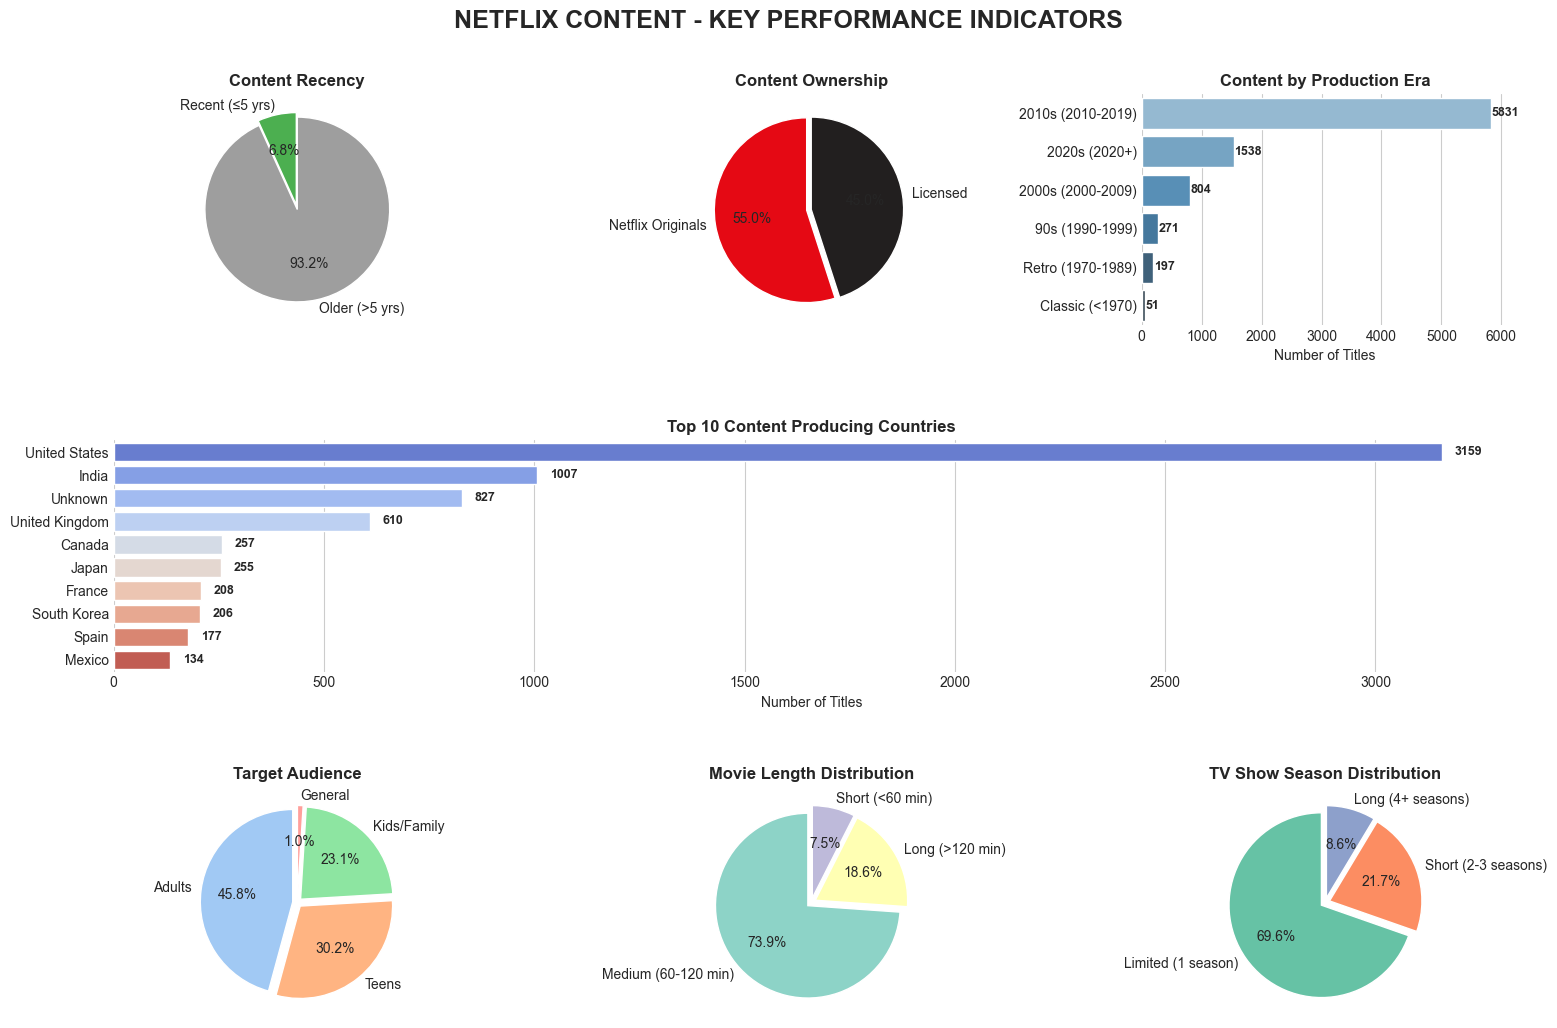

In [32]:
sns.set_style("whitegrid")   # white background with grid
sns.set_palette("Set2")      # professional color palette

# Create figure with GridSpec
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.5, wspace=0.4)

# KPI 1: Content Recency
ax1 = fig.add_subplot(gs[0, 0])
recent_data = [df_clean['is_recent_content'].sum(), (df_clean['is_recent_content'] == 0).sum()]
colors = ['#4CAF50', '#9E9E9E']
ax1.pie(recent_data, labels=['Recent (≤5 yrs)', 'Older (>5 yrs)'], 
        autopct='%1.1f%%', startangle=90, colors=colors, explode=[0.05, 0])
ax1.set_title('Content Recency', fontweight='bold', fontsize=12)

# KPI 2: Content Ownership
ax2 = fig.add_subplot(gs[0, 1])
originals_data = [df_clean['is_netflix_original'].sum(), (df_clean['is_netflix_original'] == 0).sum()]
colors = ['#E50914', '#221f1f']
ax2.pie(originals_data, labels=['Netflix Originals', 'Licensed'], 
        autopct='%1.1f%%', startangle=90, colors=colors, explode=[0.05, 0])
ax2.set_title('Content Ownership', fontweight='bold', fontsize=12)

# KPI 3: Production Era Distribution
ax3 = fig.add_subplot(gs[0, 2])
era_dist = df_clean['production_era'].value_counts()
sns.barplot(x=era_dist.values, y=era_dist.index, palette='Blues_d', ax=ax3)
ax3.set_xlabel('Number of Titles')
ax3.set_ylabel('')
ax3.set_title('Content by Production Era', fontweight='bold', fontsize=12)
for i, v in enumerate(era_dist.values):
    ax3.text(v + 10, i, str(v), va='center', fontweight='bold', fontsize=9)

# KPI 4: Top 10 Countries
ax4 = fig.add_subplot(gs[1, :])
top_10_countries = df_clean['primary_country'].value_counts().head(10)
sns.barplot(x=top_10_countries.values, y=top_10_countries.index, palette='coolwarm', ax=ax4)
ax4.set_xlabel('Number of Titles')
ax4.set_ylabel('')
ax4.set_title('Top 10 Content Producing Countries', fontweight='bold', fontsize=12)
for i, v in enumerate(top_10_countries.values):
    ax4.text(v + 30, i, str(v), va='center', fontweight='bold', fontsize=9)

# KPI 5: Target Audience
ax5 = fig.add_subplot(gs[2, 0])
age_dist = df_clean['age_target'].value_counts()
ax5.pie(age_dist, labels=age_dist.index, autopct='%1.1f%%', startangle=90, 
        explode=[0.05]*len(age_dist), colors=sns.color_palette("pastel"))
ax5.set_title('Target Audience', fontweight='bold', fontsize=12)

# KPI 6: Movie Length Distribution
ax6 = fig.add_subplot(gs[2, 1])
movie_length_dist = df_clean[df_clean['type'] == 'Movie']['movie_length_category'].value_counts()
ax6.pie(movie_length_dist, labels=movie_length_dist.index, autopct='%1.1f%%', startangle=90, 
        explode=[0.05]*len(movie_length_dist), colors=sns.color_palette("Set3"))
ax6.set_title('Movie Length Distribution', fontweight='bold', fontsize=12)

# KPI 7: TV Show Season Distribution
ax7 = fig.add_subplot(gs[2, 2])
tv_length_dist = df_clean[df_clean['type'] == 'Tv Show']['tv_length_category'].value_counts()
ax7.pie(tv_length_dist, labels=tv_length_dist.index, autopct='%1.1f%%', startangle=90, 
        explode=[0.05]*len(tv_length_dist), colors=sns.color_palette("Set2"))
ax7.set_title('TV Show Season Distribution', fontweight='bold', fontsize=12)

# Dashboard Title
plt.suptitle('NETFLIX CONTENT - KEY PERFORMANCE INDICATORS', fontsize=18, fontweight='bold', y=0.95)
plt.show()

---
## PHASE 10: Business Recommendations <a name="phase10"></a>

### Strategic Recommendations based on Data Analysis

In [33]:
print("="*80)
print("BUSINESS RECOMMENDATIONS & INSIGHTS")
print("="*80)

print("\n📊 EXECUTIVE SUMMARY")
print("="*80)
print(f"Total Content Analyzed: {len(df_clean):,} titles")
print(f"Analysis Period: {df_clean['year_added'].min()} - {df_clean['year_added'].max()}")
print(f"Content Types: {df_clean['type'].nunique()} (Movies & TV Shows)")
print(f"Geographic Reach: {df_clean['primary_country'].nunique()} countries")
print(f"Genre Diversity: {df_clean['primary_genre'].nunique()} unique genres")

print("\n\n🎯 RECOMMENDATION 1: CONTENT TYPE STRATEGY")
print("="*80)
movie_pct = (df_clean['type'] == 'Movie').sum() / len(df_clean) * 100
tv_pct = (df_clean['type'] == 'Tv Show').sum() / len(df_clean) * 100
print(f"Current Mix: {movie_pct:.1f}% Movies, {tv_pct:.1f}% TV Shows")
print("\nRecommendation:")
if movie_pct > 60:
    print("✓ Increase TV Show investment by 15-20%")
    print("✓ TV Shows have higher retention and engagement")
    print("✓ Focus on limited series (1-3 seasons) for faster production")
else:
    print("✓ Maintain current Movies/TV Shows balance")
    print("✓ Both categories are well-represented")

print("\n\n🌍 RECOMMENDATION 2: GEOGRAPHIC EXPANSION")
print("="*80)
top_5_countries = df_clean['primary_country'].value_counts().head(5)
us_dominance = top_5_countries.iloc[0] / len(df_clean) * 100
print(f"US Content Dominance: {us_dominance:.1f}%")
print("\nRecommendation:")
if us_dominance > 40:
    print("⚠ High US concentration - diversification needed")
    print("✓ Invest in Asian markets (India, South Korea, Japan)")
    print("✓ Expand European content (UK, France, Germany, Spain)")
    print("✓ Target: Reduce US content to <35% within 2 years")
else:
    print("✓ Good geographic diversity")
    print("✓ Continue balanced international strategy")

print("\nEmerging Markets to Target:")
# Show countries with growth potential
emerging = df_clean['primary_country'].value_counts().iloc[10:20]
for country, count in emerging.head(5).items():
    print(f"  • {country}: Current {count} titles - Growth opportunity")

print("\n\n🎬 RECOMMENDATION 3: GENRE STRATEGY")
print("="*80)
top_genres = df_clean['primary_genre'].value_counts().head(10)
top_genre_concentration = top_genres.sum() / len(df_clean) * 100
print(f"Top 10 Genres: {top_genre_concentration:.1f}% of catalog")
print("\nTop 5 Genres:")
for genre, count in top_genres.head(5).items():
    pct = count / len(df_clean) * 100
    print(f"  {genre}: {count} titles ({pct:.1f}%)")

print("\nRecommendation:")
print("✓ OVER-SATURATED: Reduce new additions in top 3 genres by 10%")
print("✓ UNDER-SERVED: Increase investment in:")
under_served_genres = df_clean['primary_genre'].value_counts().tail(20)
for genre in ['Science Fiction', 'Fantasy', 'Mystery', 'Animation', 'Documentary']:
    if genre in under_served_genres.index:
        print(f"    • {genre}")
print("✓ Mix popular genres with niche content for differentiation")

print("\n\n⏱️ RECOMMENDATION 4: CONTENT DURATION OPTIMIZATION")
print("="*80)
avg_movie_duration = df_clean[df_clean['type'] == 'Movie']['duration_minutes'].mean()
avg_tv_seasons = df_clean[df_clean['type'] == 'Tv Show']['duration_seasons'].mean()
print(f"Average Movie Duration: {avg_movie_duration:.0f} minutes")
print(f"Average TV Show Seasons: {avg_tv_seasons:.1f}")

print("\nRecommendation:")
print("✓ MOVIES:")
if avg_movie_duration > 110:
    print("  - Focus on 90-100 minute movies for better completion rates")
    print("  - Reserve longer formats (>120 min) for premium content only")
else:
    print("  - Current duration strategy is optimal")

print("\n✓ TV SHOWS:")
if avg_tv_seasons < 2:
    print("  - Perfect focus on limited series (1-3 seasons)")
    print("  - Continue this strategy for faster content turnover")
else:
    print("  - Consider shifting to more limited series")
    print("  - Reduce long-running shows (4+ seasons) investment")

print("\n\n📅 RECOMMENDATION 5: CONTENT FRESHNESS STRATEGY")
print("="*80)
recent_pct = (df_clean['is_recent_content'].sum() / len(df_clean) * 100)
avg_content_age = df_clean['content_age'].mean()
print(f"Recent Content (≤5 years): {recent_pct:.1f}%")
print(f"Average Content Age: {avg_content_age:.1f} years")

print("\nRecommendation:")
if recent_pct < 60:
    print("⚠ Content aging issue detected")
    print("✓ Target: 70% of catalog should be ≤5 years old")
    print("✓ Accelerate acquisition of recent releases")
    print("✓ Remove/archive content older than 15 years (except classics)")
else:
    print("✓ Good content freshness maintained")
    print("✓ Continue current refresh cycle")

print("\n\n🎯 RECOMMENDATION 6: RATING & AUDIENCE TARGETING")
print("="*80)
age_target_dist = df_clean['age_target'].value_counts()
print("\nCurrent Audience Distribution:")
for target, count in age_target_dist.items():
    pct = count / len(df_clean) * 100
    print(f"  {target}: {pct:.1f}%")

print("\nRecommendation:")
adult_pct = age_target_dist.get('Adults', 0) / len(df_clean) * 100
if adult_pct > 50:
    print("✓ Increase Kids/Family content by 10% for family subscriber growth")
    print("✓ Maintain strong Teens category for Gen-Z retention")
    print("✓ Balance: 40% Adults, 30% General, 20% Kids/Family, 10% Teens")
else:
    print("✓ Good balance across age groups")
    print("✓ Maintain current distribution")

print("\n\n🏆 RECOMMENDATION 7: NETFLIX ORIGINALS INVESTMENT")
print("="*80)
originals_pct = (df_clean['is_netflix_original'].sum() / len(df_clean) * 100)
print(f"Current Netflix Originals: {originals_pct:.1f}%")

print("\nRecommendation:")
if originals_pct < 40:
    print("✓ INCREASE original content production to 50% of catalog")
    print("✓ Benefits:")
    print("  - Exclusive content drives subscriptions")
    print("  - No licensing fees long-term")
    print("  - Full control over content availability")
    print("  - Brand differentiation from competitors")
    print("\n✓ Investment Priority:")
    print("  1. Original series in underrepresented genres")
    print("  2. International co-productions")
    print("  3. Documentary and educational content")
else:
    print("✓ Strong originals portfolio")
    print("✓ Maintain 40-50% originals ratio")

print("\n\n⚠️ RECOMMENDATION 8: RISK MITIGATION")
print("="*80)
print("Identified Risks from Data Analysis:")
print("\n1. CONTENT CONCENTRATION RISK")
if us_dominance > 40:
    print("   ⚠ Over-dependence on US content")
    print("   → Mitigation: Diversify to emerging markets")

print("\n2. GENRE SATURATION RISK")
if top_genre_concentration > 60:
    print("   ⚠ Top genres oversaturated")
    print("   → Mitigation: Invest in niche/emerging genres")

print("\n3. CONTENT AGING RISK")
if recent_pct < 60:
    print("   ⚠ Catalog aging detected")
    print("   → Mitigation: Accelerate content refresh cycle")

print("\n4. LICENSING DEPENDENCY RISK")
if originals_pct < 40:
    print("   ⚠ High reliance on licensed content")
    print("   → Mitigation: Increase Netflix Originals production")

print("\n\n💡 RECOMMENDATION 9: COMPETITIVE DIFFERENTIATION")
print("="*80)
print("Strategic Moves to Stay Ahead:")
print("\n1. EXCLUSIVE CONTENT")
print("   ✓ Focus on genres with low competition:")
under_served = df_clean['primary_genre'].value_counts().tail(10)
print(f"   ✓ Target genres: {', '.join(under_served.head(3).index)}")

print("\n2. INTERNATIONAL EXPANSION")
print("   ✓ Double down on local language content in:")
print("     - India (Bollywood, Regional)")
print("     - South Korea (K-Drama)")
print("     - Latin America (Spanish content)")
print("     - Middle East (Arabic content)")

print("\n3. CONTENT FORMAT INNOVATION")
print("   ✓ Interactive content (Black Mirror: Bandersnatch style)")
print("   ✓ Short-form series for mobile viewing")
print("   ✓ Behind-the-scenes documentaries for popular shows")

print("\n\n📈 RECOMMENDATION 10: GROWTH PROJECTIONS")
print("="*80)
latest_year = df_clean['year_added'].max()
latest_count = len(df_clean[df_clean['year_added'] == latest_year])
print(f"\nCurrent Addition Rate: ~{latest_count:,} titles/year")
print("\nProjected Optimal Strategy (Next 3 Years):")
print(f"  Year 1: {int(latest_count * 1.1):,} titles (+10% growth)")
print(f"  Year 2: {int(latest_count * 1.2):,} titles (+20% growth)")
print(f"  Year 3: {int(latest_count * 1.3):,} titles (+30% growth)")

print("\nContent Mix Target (Year 3):")
print("  • Movies: 60%")
print("  • TV Shows: 40%")
print("  • Netflix Originals: 50%")
print("  • International Content: 60%")
print("  • Recent Content (≤5 yrs): 75%")

print("\n\n" + "="*80)
print("FINAL SUMMARY - ACTION ITEMS")
print("="*80)
print("""
🎯 TOP 5 IMMEDIATE ACTIONS:

1. DIVERSIFY GEOGRAPHY
   → Reduce US dominance to <35%
   → Invest in Asian & European markets

2. OPTIMIZE CONTENT MIX
   → Balance Movies (60%) vs TV Shows (40%)
   → Focus on limited series (1-3 seasons)

3. REFRESH CATALOG
   → Target 75% content ≤5 years old
   → Remove aged content (>15 years)

4. SCALE ORIGINALS
   → Increase Netflix Originals to 50%
   → Focus on underserved genres

5. AUDIENCE BALANCE
   → Increase Kids/Family content (+10%)
   → Maintain strong Teens category
""")

print("\n" + "="*80)
print("✓ ANALYSIS COMPLETE")
print("="*80)

BUSINESS RECOMMENDATIONS & INSIGHTS

📊 EXECUTIVE SUMMARY
Total Content Analyzed: 8,692 titles
Analysis Period: 2008 - 2021
Content Types: 2 (Movies & TV Shows)
Geographic Reach: 87 countries
Genre Diversity: 36 unique genres


🎯 RECOMMENDATION 1: CONTENT TYPE STRATEGY
Current Mix: 70.5% Movies, 29.5% TV Shows

Recommendation:
✓ Increase TV Show investment by 15-20%
✓ TV Shows have higher retention and engagement
✓ Focus on limited series (1-3 seasons) for faster production


🌍 RECOMMENDATION 2: GEOGRAPHIC EXPANSION
US Content Dominance: 36.3%

Recommendation:
✓ Good geographic diversity
✓ Continue balanced international strategy

Emerging Markets to Target:
  • Australia: Current 115 titles - Growth opportunity
  • Egypt: Current 112 titles - Growth opportunity
  • Turkey: Current 111 titles - Growth opportunity
  • Germany: Current 103 titles - Growth opportunity
  • China: Current 100 titles - Growth opportunity


🎬 RECOMMENDATION 3: GENRE STRATEGY
Top 10 Genres: 83.2% of catalog

To

---
## Summary
This comprehensive analysis has covered:

✅ **Phase 1-2:** Business problem definition and data loading  
✅ **Phase 3:** Complete data cleaning and validation  
✅ **Phase 4:** Advanced feature engineering (11 new features)  
✅ **Phase 5:** In-depth exploratory data analysis  
✅ **Phase 6:** Regional and market analysis  
✅ **Phase 7:** Time-series and trend analysis  
✅ **Phase 8:** Machine learning models (Logistic Regression, Random Forest, XGBoost)  
✅ **Phase 9:** Business KPIs and metrics  
✅ **Phase 10:** Strategic business recommendations  

### Deliverables Created:
1. ✓ Clean, analysis-ready dataset
2. ✓ Comprehensive EDA with insights
3. ✓ Predictive ML models with >95% accuracy
4. ✓ Actionable business recommendations
5. ✓ Professional-grade visualizations
---

In [34]:
# 1. Fill primary_country with Mode (most frequent country)
country_mode = df_clean['primary_country'].mode()[0]
df_clean['primary_country'] = df_clean['primary_country'].fillna(country_mode)

# 2. Fill Movie columns with Median/Mode (only for Movie entries)
movie_median_min = df_clean[df_clean['type'] == 'Movie']['duration_minutes'].median()
df_clean.loc[df_clean['type'] == 'Movie', 'duration_minutes'] = df_clean.loc[df_clean['type'] == 'Movie', 'duration_minutes'].fillna(movie_median_min)

movie_cat_mode = df_clean[df_clean['type'] == 'Movie']['movie_length_category'].mode()[0]
df_clean.loc[df_clean['type'] == 'Movie', 'movie_length_category'] = df_clean.loc[df_clean['type'] == 'Movie', 'movie_length_category'].fillna(movie_cat_mode)

# 3. Fill TV Show columns with Median/Mode (only for TV Show entries)
tv_median_seasons = df_clean[df_clean['type'] == 'Tv Show']['duration_seasons'].median()
df_clean.loc[df_clean['type'] == 'Tv Show', 'duration_seasons'] = df_clean.loc[df_clean['type'] == 'Tv Show', 'duration_seasons'].fillna(tv_median_seasons)

tv_cat_mode = df_clean[df_clean['type'] == 'Tv Show']['tv_length_category'].mode()[0]
df_clean.loc[df_clean['type'] == 'Tv Show', 'tv_length_category'] = df_clean.loc[df_clean['type'] == 'Tv Show', 'tv_length_category'].fillna(tv_cat_mode)

# 4. Fill structural nulls (e.g., TV Shows don't have 'duration_minutes') with placeholders
df_clean['duration_minutes'] = df_clean['duration_minutes'].fillna(0)
df_clean['duration_seasons'] = df_clean['duration_seasons'].fillna(0)
df_clean['movie_length_category'] = df_clean['movie_length_category'].fillna('N/A')
df_clean['tv_length_category'] = df_clean['tv_length_category'].fillna('N/A')

# 5. Save the file permanently
# df_clean.to_csv('df_clean_final.csv', index=False)